# Analiza in napoved kriminalitete v slovenskih občinah

# Uvod

Cilj tega projekta je iz podatkov o kriminaliteti po Sloveniji zgraditi modele, ki pomagajo razumeti vzorce kaznivih dejanj in omogočajo osnovno napovedovanje tveganja za posamezne upravne enote. Osrednji cilj je regresijski ali klasifikacijski model, ki oceni verjetnost in obseg kriminalitete v posameznem letu, hkrati pa raziskuje vpliv demografskih in socialnih dejavnikov.

Osnovni dataset vsebuje število kaznivih dejanj po upravnih enotah in letih, razdeljeno po kategorijah (npr. tatvine, nasilje, premoženjska kriminaliteta). Ker podatki iz policijskih evidenc sami po sebi ne nudijo dovolj informacij za podrobno analizo, jih nadgradimo z:  

- demografskimi podatki (prebivalstvo, spol, starostne skupine, državljanstvo) iz SURS-a  
- podatki o izobrazbi in drugih socialno-ekonomskih značilnostih prebivalstva  
- združevanjem podatkov po upravnih enotah, da omogočimo primerjave med regijami  

V tem projektu so prikazani vsi koraki analize:  

1. čiščenje in priprava podatkov (odstranjevanje manjkajočih in neznanih vrednosti, standardizacija imen občin)  
2. združevanje podatkov iz različnih virov na ravni upravnih enot in let  
3. analiza časovnih trendov in prostorskih razlik v kriminaliteti  
4. vizualizacije za boljše razumevanje vzorcev  
5. regresijski in klasifikacijski pristopi za napovedovanje števila kaznivih dejanj  
6. interpretacija rezultatov in priporočila za nadaljnje raziskave ali uporabo modelov  

**Pomembna omejitev:** modeli temeljijo le na evidentiranih kaznivih dejanjih, zato napovedi odražajo verjetnost in obseg prijavljenih oziroma zaznanih primerov kriminalitete, ne pa celotne populacije potencialnih kaznivih dejanj.


#IMPORTI

In [50]:
import pandas as pd
import numpy as np
from functools import reduce
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



# 1. PRIPRAVA IN ČIŠČENJE DATASET-OV


*OPOMBA*

V vseh datasetih manjkajo podatki za Ankaran leta 2014, saj je nova občinska uprava začela z delovanjem šele 1. januarja 2015, zato so podatki leta 2014 za Ankaran že šteti k podatkov za Koper.

### KRIMINALITETA
Podatki o kaznivih dejanjih so bili pridobljeni december 2025 s spletne strani
https://www.policija.si/o-slovenski-policiji/statistika/kriminaliteta
Uporabljeni so podatki številu kaznivih dejanj po upravnih enotah, v zadnjih 11 letih, oziroma od 2014 do 2024


*OPOMBA*

Prvoten plan projekta je bil napoved kriminalitete po slovenskih občinah ampak ker policija kazniva dejanja beleži zgolj po upravnih enotah sem vse podatke, ki so bili pridobljeni na nivoju občin, združil v upravne enote. Podatke o upravnih enotah in pripadajočih občinah sem pridobil na spletni strani
https://www.stat.si/Klasje/Klasje/Details/1476
in jih potem preuredil v excel tablo "ue_obcine.xlsx"


Preberemo in združimo vse datoteke, hkrati pa preverimo, če imamo kaj manjkajočih podatkov za nam relevantne lastnosti (Upravne enote)

In [51]:
dfs_kriminaliteta = []

for leto in range(2014, 2025):
    df = pd.read_csv(
        f"kd{leto}.csv",
        encoding="cp1250",
        sep=";",
        engine="python"
    )
    df["leto"] = leto
    dfs_kriminaliteta.append(df)

df_kriminaliteta_raw = pd.concat(dfs_kriminaliteta, ignore_index=True)


df_kriminaliteta_raw['UpravnaEnotaStoritve'].isna().sum()

np.int64(0)

In [52]:
df_kriminaliteta_raw['UpravnaEnotaStoritve'].value_counts()

,count
UpravnaEnotaStoritve,
LJUBLJANA,380404
MARIBOR,87606
CELJE,46988
NOVO MESTO,43436
KRANJ,38110
...,...
TRŽIČ,4048
ORMOŽ,3790
RADLJE OB DRAVI,3387


Poenotimo ime stolpca in grupiramo kazniva dejanja, da dobimo števila kaznivih dejanj po posameznih upravnih enotah za posamezna leta

In [53]:
df_kriminaliteta_raw["Upravna_enota"] = (
    df_kriminaliteta_raw["UpravnaEnotaStoritve"]
    .str.strip()
    .str.upper()
)


df_kriminaliteta = (
    df_kriminaliteta_raw
    .groupby(["Upravna_enota", "leto"])
    .size()
    .reset_index(name="st_kaznivih_dejanj")
    .sort_values(["leto", "Upravna_enota"])
    .reset_index(drop=True)
)

Odstranimo podatke, kjer je upravna enota storitve neznana, saj nam ne koristi (prej smo ugotovili, da nimamo manjkajočih vrednosti, ampak so neznane vrednosti v stolpcu Upravna enote, zapisane kar kot "Neznana UE" ali "Neznana obč")

In [54]:
ue_obcine = pd.read_excel("ue_obcine.xlsx")
ue_obcine["Upravna_enota"] = ue_obcine["Upravna enota"].str.strip()
ue_obcine["Občina"] = ue_obcine["Občina"].str.strip()

valid_ue = ue_obcine["Upravna_enota"].unique()

df_kriminaliteta = df_kriminaliteta[
    df_kriminaliteta["Upravna_enota"].isin(valid_ue)
].reset_index(drop=True)

print(df_kriminaliteta.head())
print(df_kriminaliteta.shape)


  Upravna_enota  leto  st_kaznivih_dejanj
0    AJDOVŠČINA  2014                 728
1       BREŽICE  2014                1632
2         CELJE  2014                6387
3      CERKNICA  2014                 432
4       DOMŽALE  2014                4709
(638, 3)


###  SESTAVA PREBIVALSTVA

Tabela o osnovni demografski sliki pridobljena s https://pxweb.stat.si/SiStatData/pxweb/sl/Data/Data/05E1022S.px/

Vsebuje podatke o številu prebivalcev, državljanov RS in tujcev po slovenskih občinah, ločeno po spolu, za drugo polletje zadnjih 10 let, oziroma od 2014 do 2024.

Najprej tabelo preberemo in spremenimo it multi-header wide formata v lepši one-line header

In [55]:
df = pd.read_excel("prebivalstvo.xlsx", header=[0, 1, 2])
df = df.replace("-", np.nan)

# Preimenuj stolpce (3-level → 1-level)
df.columns = [
    "Občina" if c[0].startswith("Unnamed") else f"{c[0]}_{c[1]}_{c[2]}"
    for c in df.columns
]

# odstrani prazne vrstice
df = df.dropna(subset=["Občina"])

# Poišči vsa H2 leta
leta_h2 = sorted({
    c.split("_")[0]
    for c in df.columns
    if c != "Občina" and c.startswith("20") and "H2" in c
})

#  Razbij po letih (wide kategorije)
records = []

for leto in leta_h2:
    cols = [c for c in df.columns if c.startswith(leto)]
    df_leto = df[["Občina"] + cols].copy()
    df_leto["leto"] = int(leto.replace("H2", ""))

    # obdrži samo kategorija + spol
    df_leto.columns = (
        ["Občina"]
        + [c.split("_", 1)[1].lower().replace(" ", "_") for c in cols]
        + ["leto"]
    )

    records.append(df_leto)

# Združi v en DataFrame
df_prebivalstvo1 = pd.concat(records, ignore_index=True)

print(df_prebivalstvo1.isna().sum())
df_prebivalstvo1.head()


Občina                                          0
prebivalstvo_spol_-_skupaj                      1
prebivalstvo_moški                              1
prebivalstvo_ženske                             1
državljani_republike_slovenije_spol_-_skupaj    1
državljani_republike_slovenije_moški            1
državljani_republike_slovenije_ženske           1
tuji_državljani_spol_-_skupaj                   1
tuji_državljani_moški                           1
tuji_državljani_ženske                          1
leto                                            0
dtype: int64


/tmp/ipython-input-304323704.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("-", np.nan)


,Občina,prebivalstvo_spol_-_skupaj,prebivalstvo_moški,prebivalstvo_ženske,državljani_republike_slovenije_spol_-_skupaj,državljani_republike_slovenije_moški,državljani_republike_slovenije_ženske,tuji_državljani_spol_-_skupaj,tuji_državljani_moški,tuji_državljani_ženske,leto
0,Ajdovščina,18892.0,9570.0,9322.0,18064.0,8999.0,9065.0,828.0,571.0,257.0,2014
1,Ankaran/Ancarano,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014
2,Apače,3605.0,1794.0,1811.0,3571.0,1777.0,1794.0,34.0,17.0,17.0,2014
3,Beltinci,8329.0,4154.0,4175.0,8251.0,4091.0,4160.0,78.0,63.0,15.0,2014
4,Benedikt,2464.0,1237.0,1227.0,2445.0,1222.0,1223.0,19.0,15.0,4.0,2014


Podatke, ki so zbrani po občinah, zdaj združimo na raven upravnih enot in posplošimo imena stolpcev.
Združevanje po upravnih enotah prav tako odstrani (ignorira) manjkajoče vrednosti.

In [56]:
ue_obcine = pd.read_excel("ue_obcine.xlsx")
ue_obcine["Upravna_enota"] = ue_obcine["Upravna enota"].str.strip()
ue_obcine["Občina"] = ue_obcine["Občina"].str.strip()

df_ue = df_prebivalstvo1.merge(
    ue_obcine[["Občina", "Upravna_enota"]],
    on="Občina",
    how="left"
)

# Numeric conversion
preb_stolpci = [c for c in df_ue.columns if c not in ["Občina", "leto", "Upravna_enota"]]
df_ue[preb_stolpci] = df_ue[preb_stolpci].apply(pd.to_numeric, errors="coerce")

#  Agregacija po UE in letu
df_prebivalstvo = (
    df_ue
    .groupby(["leto", "Upravna_enota"], as_index=False)[preb_stolpci]
    .sum()
)


df_prebivalstvo = df_prebivalstvo.rename(
    columns={"prebivalstvo_spol_-_skupaj": "Prebivalstvo",
             "prebivalstvo_moški": "Prebivalstvo_M",
             "prebivalstvo_ženske": "Prebivalstvo_Ž",
             "državljani_republike_slovenije_spol_-_skupaj" : "DržavljaniRS",
             "državljani_republike_slovenije_moški" : "DržavljaniRS_M",
             "državljani_republike_slovenije_ženske": "DržavljaniRS_Ž",
             "tuji_državljani_spol_-_skupaj" : "Tujci",
             "tuji_državljani_moški" : "Tujci_M",
             "tuji_državljani_ženske" : "Tujci_Ž"}
)

df_prebivalstvo.head()


,leto,Upravna_enota,Prebivalstvo,Prebivalstvo_M,Prebivalstvo_Ž,DržavljaniRS,DržavljaniRS_M,DržavljaniRS_Ž,Tujci,Tujci_M,Tujci_Ž
0,2014,AJDOVŠČINA,24504.0,12364.0,12140.0,23466.0,11656.0,11810.0,1038.0,708.0,330.0
1,2014,BREŽICE,24230.0,11935.0,12295.0,23151.0,11285.0,11866.0,1079.0,650.0,429.0
2,2014,CELJE,63951.0,31679.0,32272.0,59631.0,28726.0,30905.0,4320.0,2953.0,1367.0
3,2014,CERKNICA,16767.0,8535.0,8232.0,15862.0,7905.0,7957.0,905.0,630.0,275.0
4,2014,DOMŽALE,57189.0,28174.0,29015.0,55039.0,26774.0,28265.0,2150.0,1400.0,750.0


### PODATKI O DELOVNO AKTIVNIH
Pridobljeni s strani
https://pxweb.stat.si/SiStatData/pxweb/sl/Data/-/0723405S.px

Enako kot pri vseh tabelah pridobljenih s SiSTat, so tu podatki po občinah, ki sem jih združil v upravne enote.

Tudi tukaj spremenimo format iz multiheader-ja v oneline header in malo bolj pregleden long format

In [57]:
df_delovnoAktivni = pd.read_excel('delovnoAktivni.xlsx')
df_delovnoAktivni = df_delovnoAktivni.replace("-", np.nan)


df_DA_long = df_delovnoAktivni.melt(
    id_vars='Občina',
    var_name='leto',
    value_name='st_delovno_aktivnih'
)

# Tipi
df_DA_long['leto'] = df_DA_long['leto'].astype(int)

# Pretvori '-' v NaN in v numeric
df_DA_long['st_delovno_aktivnih'] = pd.to_numeric(
    df_DA_long['st_delovno_aktivnih'].replace('-', None),
    errors='coerce'
)

print(df_DA_long.iloc[df_DA_long.isna().sum()])
df_DA_long.isna().sum()


              Občina  leto  st_delovno_aktivnih
0        Ajdovščina   2014               7066.0
0        Ajdovščina   2014               7066.0
1  Ankaran/Ancarano   2014                  NaN


/tmp/ipython-input-2892088229.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_delovnoAktivni = df_delovnoAktivni.replace("-", np.nan)


,0
Občina,0
leto,0
st_delovno_aktivnih,1


In [58]:
ue_obcine = pd.read_excel("ue_obcine.xlsx")
ue_obcine['Upravna_enota'] = ue_obcine['Upravna enota'].str.strip()
ue_obcine['Občina'] = ue_obcine['Občina'].str.strip()

# Preveri tudi df_delovnoAktivni_long, da ni dodatnih presledkov
df_DA_long['Občina'] = df_DA_long['Občina'].str.strip()

# Merge delovno aktivni podatkov z UE mappingom
df_merged = df_DA_long.merge(
    ue_obcine,
    on='Občina',
    how='left'
)

# Agregacija po Upravnih enotah in letu
df_delovnoAktivni= df_merged.groupby(['leto', 'Upravna_enota'], as_index=False).agg({
    'st_delovno_aktivnih':'sum'
})

# Rezultat
df_delovnoAktivni.head(20)


,leto,Upravna_enota,st_delovno_aktivnih
0,2014,AJDOVŠČINA,9021.0
1,2014,BREŽICE,8408.0
2,2014,CELJE,23567.0
3,2014,CERKNICA,6647.0
4,2014,DOMŽALE,23178.0
5,2014,DRAVOGRAD,3106.0
6,2014,GORNJA RADGONA,6131.0
7,2014,GROSUPLJE,16431.0
8,2014,HRASTNIK,3256.0
9,2014,IDRIJA,6701.0


### STOPNJE IZOBRAZNE MED PREBIVALSTVOM

Dostopno na strani
https://pxweb.stat.si/SiStatData/pxweb/sl/Data/-/05G2014S.px




In [59]:
df = pd.read_excel("izobrazba.xlsx", header=[0, 1])
df = df.replace("-", np.nan)
print(df.isna().sum())


#  popravi prvi stolpec (Občina)
df.columns = pd.MultiIndex.from_tuples([
    ('Občina', '') if 'Občina' in str(col[1]) else col
    for col in df.columns
])

#  odstrani Občino iz MultiIndexa
df = df.set_index(('Občina',''))

#  zamenjaj "-" z NaN in popravi tipe
df = df.replace('-', np.nan).infer_objects(copy=False)

# stack: leto + izobrazba → long
df_long = (
    df
    .stack(level=[0, 1])
    .reset_index()
)

df_long.columns = ['Občina', 'leto', 'izobrazba', 'stevilo']

# pivot v KONČNI FORMAT
df_final = (
    df_long
    .pivot_table(
        index=['Občina', 'leto'],
        columns='izobrazba',
        values='stevilo',
        aggfunc='sum'
    )
    .reset_index()
)


Unnamed: 0_level_0  Občina                                     0
2014                Osnovnošolska ali manj - Skupaj            1
                    Brez izobrazbe, nepopolna osnovnošolska    1
                    Osnovnošolska                              1
                    Srednješolska - Skupaj                     1
                                                              ..
2024                Srednješolska - Skupaj                     0
                    Višješolska, visokošolska - Skupaj         0
                    Visokošolska 1. stopnje ipd.               0
                    Visokošolska 2. stopnje ipd.               0
                    Visokošolska 3. stopnje ipd.               0
Length: 89, dtype: int64


/tmp/ipython-input-515723818.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("-", np.nan)
/tmp/ipython-input-515723818.py:21: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(level=[0, 1])


In [60]:
#agregacija po Upravnih ENotah

# 1️⃣ Preberi mapping Občina → Upravna enota
ue = pd.read_excel("ue_obcine.xlsx")[['Občina', 'Upravna enota']]
ue['Občina'] = ue['Občina'].str.strip()
ue['Upravna_enota'] = ue['Upravna enota'].str.strip()

# 2️⃣ Merge z izobrazbenimi podatki
df_ue = df_final.merge(ue, on='Občina', how='left')

# Opcijsko: preveri občine brez UE
missing = df_ue[df_ue['Upravna_enota'].isna()]
if not missing.empty:
    print("Občine brez UE:", missing['Občina'].unique())

# 3️⃣ Izberi stolpce izobrazbe
izobrazba_cols = df_final.columns.difference(['Občina', 'leto'])

# 4️⃣ Agregacija po Upravnih enotah in letu
df_izobrazba = (
    df_ue
    .groupby(['leto', 'Upravna_enota'], as_index=False)[izobrazba_cols]
    .sum()
)
df_izobrazba["leto"] = pd.to_numeric(df_izobrazba["leto"], errors="coerce").astype("int64")
df_izobrazba = df_izobrazba.drop(
    columns=[
        "Osnovnošolska ali manj - Skupaj",
        "Višješolska, visokošolska - Skupaj"
    ],
    errors="ignore"  # da ne pade, če kdaj katerega ni
)
df_izobrazba = df_izobrazba.rename(columns={
    "Brez izobrazbe, nepopolna osnovnošolska" : "BrezIzobrazbe_nepopolnaOŠ",
    "Srednješolska - Skupaj" : "Srednješolska_Skupaj",
    "Visokošolska 1. stopnje ipd." : "Visokošolska_1",
    "Visokošolska 2. stopnje ipd." : "Visokošolska_2",
    "Visokošolska 3. stopnje ipd." : "Visokošolska_3"
})
df_izobrazba.head()



,leto,Upravna_enota,BrezIzobrazbe_nepopolnaOŠ,Osnovnošolska,Srednješolska_Skupaj,Visokošolska_1,Visokošolska_2,Visokošolska_3
0,2014,AJDOVŠČINA,568.0,5732.0,10185.0,1790.0,1894.0,241.0
1,2014,BREŽICE,1069.0,4815.0,11418.0,1836.0,1652.0,159.0
2,2014,CELJE,1950.0,11888.0,29342.0,5464.0,5334.0,862.0
3,2014,CERKNICA,572.0,3533.0,7370.0,1363.0,1200.0,138.0
4,2014,DOMŽALE,1286.0,10002.0,25064.0,4789.0,4906.0,1040.0


### Starostne Skupine
Dostopno na https://pxweb.stat.si/SiStatData/pxweb/sl/Data/Data/05C4006S.px/

Preberemo datoteko in uredimo format.

In [61]:
df = pd.read_excel("starostneSkupine.xlsx", header=[0,1])
df = df.replace("-", np.nan)

#  Preimenujmo "Občine" stolpec
df.columns = [f"{l[0]}_{l[1]}" if l[0] != 'Unnamed: 0_level_0' else 'Občina' for l in df.columns]

# Zamenjamo '-' z NaN
df = df.replace('-', np.nan)

#  Poiščemo vsa H2 leta
leto_h2 = sorted(set([c.split('_')[0] for c in df.columns if c != 'Občina']))

#  Združimo po letih v long format z wide starostnimi skupinami
records = []
for leto in leto_h2:
    cols = [c for c in df.columns if c.startswith(leto)]
    df_leto = df[['Občina'] + cols].copy()
    df_leto['leto'] = int(leto.replace('H2',''))
    # preimenujemo stolpce, da ostanejo samo starostne skupine
    df_leto.columns = ['Občina'] + [c.split('_')[1] for c in cols] + ['leto']
    records.append(df_leto)

#  Združimo vse v en DataFrame
df_starost1 = pd.concat(records, ignore_index=True)

df_starost1 = df_starost1[['Občina','leto'] + [c for c in df_starost1.columns if c not in ['Občina','leto']]]
print(df_starost1.isna().sum())
df_starost1.head()

Občina       0
leto         0
0-14 let     1
15-18 let    1
19-26 let    1
15-49 let    1
15-64 let    1
65 + let     1
dtype: int64


/tmp/ipython-input-1072347977.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("-", np.nan)


,Občina,leto,0-14 let,15-18 let,19-26 let,15-49 let,15-64 let,65 + let
0,Ajdovščina,2014,3123.0,717.0,1488.0,8403.0,12532.0,3237.0
1,Ankaran/Ancarano,2014,NaN,NaN,NaN,NaN,NaN,NaN
2,Apače,2014,485.0,125.0,292.0,1658.0,2514.0,606.0
3,Beltinci,2014,1201.0,349.0,694.0,3912.0,5731.0,1397.0
4,Benedikt,2014,445.0,114.0,248.0,1251.0,1719.0,300.0


Združimo občine v pripadajoče upravne enote in uredimo starostne skupine v bolj smiselno razporeditev

In [62]:
# Merge s tabelo UE
df_ue = df_starost1.merge(ue_obcine[['Občina','Upravna_enota']], on='Občina', how='left')


# Pretvori vse starostne stolpce v numeric (če slučajno obstaja '-')
starostni_stolpci = [c for c in df_ue.columns if c not in ['Občina','leto','Upravna_enota']]
df_ue[starostni_stolpci] = df_ue[starostni_stolpci].replace('-', np.nan).apply(pd.to_numeric, errors='coerce')

# Preveri manjkajoče UE
missing_ue = df_ue[df_ue['Upravna_enota'].isna()]
if not missing_ue.empty:
    print("Manjkajoče UE za naslednje občine:")
    print(missing_ue['Občina'].unique())

# Agregacija po Upravnih enotah in letu
df_starostneSkupine = df_ue.groupby(['leto', 'Upravna_enota'])[starostni_stolpci].sum().reset_index()

# Preuredimo stolpce
df_starostneSkupine['27-64 let'] = df_starostneSkupine['15-64 let'] - df_starostneSkupine['15-18 let'] - df_starostneSkupine['19-26 let']
df_starostneSkupine = df_starostneSkupine.drop(columns=['15-64 let', '15-49 let'])
starostni_red = ['0-14 let', '15-18 let', '19-26 let', '27-64 let', '65 + let']
cols = ['leto', 'Upravna_enota'] + [c for c in starostni_red if c in df_starostneSkupine.columns]
df_starostneSkupine = df_starostneSkupine[cols]

#  Končni rezultat
df_starostneSkupine.head()



,leto,Upravna_enota,0-14 let,15-18 let,19-26 let,27-64 let,65 + let
0,2014,AJDOVŠČINA,4065.0,965.0,1949.0,13283.0,4242.0
1,2014,BREŽICE,3328.0,877.0,1880.0,13436.0,4709.0
2,2014,CELJE,9121.0,2362.0,4916.0,35719.0,11833.0
3,2014,CERKNICA,2554.0,680.0,1391.0,8961.0,3181.0
4,2014,DOMŽALE,9983.0,2354.0,5239.0,30674.0,8939.0


# 2. Predprocesiranje podatkov

Prebrali in predelali smo vse datoteke, zdaj pa pred nadaljnim delom poglejmo zanimive lastnostni sestave prebivalstva po upravnih enotah.

Vse ločene dataframe združimo v en velik master dataframe

In [63]:
# ZDRUZITEV V EN DATAFRAME

dfs = [
    df_kriminaliteta,
    df_prebivalstvo,
    df_starostneSkupine,
    df_delovnoAktivni,
    df_izobrazba
]

df_master = reduce(
    lambda left, right: pd.merge(
        left,
        right,
        on=["Upravna_enota", "leto"],
        how="outer"
    ),
    dfs
)

df_master = df_master.sort_values(
    ["leto", "Upravna_enota"]
).reset_index(drop=True)

df_master.to_csv("df_master.csv", index=False, sep=';')
df_master.head()



,Upravna_enota,leto,st_kaznivih_dejanj,Prebivalstvo,Prebivalstvo_M,Prebivalstvo_Ž,DržavljaniRS,DržavljaniRS_M,DržavljaniRS_Ž,Tujci,...,19-26 let,27-64 let,65 + let,st_delovno_aktivnih,BrezIzobrazbe_nepopolnaOŠ,Osnovnošolska,Srednješolska_Skupaj,Visokošolska_1,Visokošolska_2,Visokošolska_3
0,AJDOVŠČINA,2014,728,24504.0,12364.0,12140.0,23466.0,11656.0,11810.0,1038.0,...,1949.0,13283.0,4242.0,9021.0,568.0,5732.0,10185.0,1790.0,1894.0,241.0
1,BREŽICE,2014,1632,24230.0,11935.0,12295.0,23151.0,11285.0,11866.0,1079.0,...,1880.0,13436.0,4709.0,8408.0,1069.0,4815.0,11418.0,1836.0,1652.0,159.0
2,CELJE,2014,6387,63951.0,31679.0,32272.0,59631.0,28726.0,30905.0,4320.0,...,4916.0,35719.0,11833.0,23567.0,1950.0,11888.0,29342.0,5464.0,5334.0,862.0
3,CERKNICA,2014,432,16767.0,8535.0,8232.0,15862.0,7905.0,7957.0,905.0,...,1391.0,8961.0,3181.0,6647.0,572.0,3533.0,7370.0,1363.0,1200.0,138.0
4,DOMŽALE,2014,4709,57189.0,28174.0,29015.0,55039.0,26774.0,28265.0,2150.0,...,5239.0,30674.0,8939.0,23178.0,1286.0,10002.0,25064.0,4789.0,4906.0,1040.0


Dodamo stolpce za lažjo analizo

In [64]:

df_master['kriminaliteta_na_1000_preb'] = (df_master['st_kaznivih_dejanj'] / df_master['Prebivalstvo']) * 1000

# Izračunamo deleže, ki bodo koristni za strojno učenje
df_master['delez_moskih'] = df_master['Prebivalstvo_M'] / df_master['Prebivalstvo']
df_master['delez_tujcev'] = df_master['Tujci'] / df_master['Prebivalstvo']
df_master["delez_zensk"] = df_master["Prebivalstvo_Ž"] / df_master["Prebivalstvo"]
df_master["delez_delovno_aktivnih"] = df_master["st_delovno_aktivnih"] / df_master["Prebivalstvo"]
df_master["delez_drzavljani_rs"]       = df_master["DržavljaniRS"] / df_master["Prebivalstvo"]
df_master["delez_tujcev_m"]            = df_master["Tujci_M"] / df_master["Prebivalstvo"]
df_master["delez_tujcev_z"]            = df_master["Tujci_Ž"] / df_master["Prebivalstvo"]

# Izobrazba (deleži)
df_master['delez_edu_brez'] = df_master['BrezIzobrazbe_nepopolnaOŠ'] / df_master['Prebivalstvo']
df_master["delez_edu_low"]  = df_master["Osnovnošolska"] / df_master["Prebivalstvo"]
df_master["delez_edu_mid"]  = df_master["Srednješolska_Skupaj"] / df_master["Prebivalstvo"]
df_master["delez_edu_high"] = (df_master["Visokošolska_1"] + df_master["Visokošolska_2"]) / df_master["Prebivalstvo"]
df_master["delez_edu_very_high"] =  df_master["Visokošolska_3"] / df_master["Prebivalstvo"]

# Starostne skupine (deleži)
df_master["delez_age_0_14"]  = df_master["0-14 let"] / df_master["Prebivalstvo"]
df_master["delez_age_19_26"] = df_master["19-26 let"] / df_master["Prebivalstvo"]
df_master["delez_age_27_64"] = df_master["27-64 let"] / df_master["Prebivalstvo"]
df_master["delez_age_65p"]   = df_master["65 + let"] / df_master["Prebivalstvo"]

# Preverimo rezultat
print(f"Velikost združenega dataseta: {df_master.shape}")
print(df_master.head())

# Preverimo, če imamo kaj manjkajočih vrednosti
print("\nManjkajoče vrednosti:")
print(df_master.isna().sum())

Velikost združenega dataseta: (638, 41)
  Upravna_enota  leto  st_kaznivih_dejanj  Prebivalstvo  Prebivalstvo_M  \
0    AJDOVŠČINA  2014                 728       24504.0         12364.0   
1       BREŽICE  2014                1632       24230.0         11935.0   
2         CELJE  2014                6387       63951.0         31679.0   
3      CERKNICA  2014                 432       16767.0          8535.0   
4       DOMŽALE  2014                4709       57189.0         28174.0   

   Prebivalstvo_Ž  DržavljaniRS  DržavljaniRS_M  DržavljaniRS_Ž   Tujci  ...  \
0         12140.0       23466.0         11656.0         11810.0  1038.0  ...   
1         12295.0       23151.0         11285.0         11866.0  1079.0  ...   
2         32272.0       59631.0         28726.0         30905.0  4320.0  ...   
3          8232.0       15862.0          7905.0          7957.0   905.0  ...   
4         29015.0       55039.0         26774.0         28265.0  2150.0  ...   

   delez_tujcev_z  delez_edu

In [65]:
print(df_master.describe().T[['mean','std','min','max']].round(2))


                                mean       std      min        max
leto                         2019.00      3.16  2014.00    2024.00
st_kaznivih_dejanj           1858.17   4681.12   120.00   55250.00
Prebivalstvo                36015.03  49457.88  8345.00  375719.00
Prebivalstvo_M              17990.96  24173.17  4228.00  183674.00
Prebivalstvo_Ž              18024.07  25290.30  4096.00  192045.00
DržavljaniRS                33471.70  44577.76  7735.00  331569.00
DržavljaniRS_M              16332.73  21070.92  3878.00  156365.00
DržavljaniRS_Ž              17125.18  23514.15  3857.00  175722.00
Tujci                        2543.33   5116.39   202.00   46999.00
Tujci_M                      1651.17   3234.43   120.00   27950.00
Tujci_Ž                       891.91   1894.40    60.00   19049.00
0-14 let                     5374.92   7350.77  1049.00   55947.00
15-18 let                    1323.55   1720.49   282.00   15202.00
19-26 let                    2896.09   5052.30   559.00   3940

# 3. VIZUALIZACIJA

####Skupno število kaznivih dejanj po letih (vse UE)
 Da vidimo časovni trend na nacionalni ravni in ugotovimo, ali je upad ali rast.

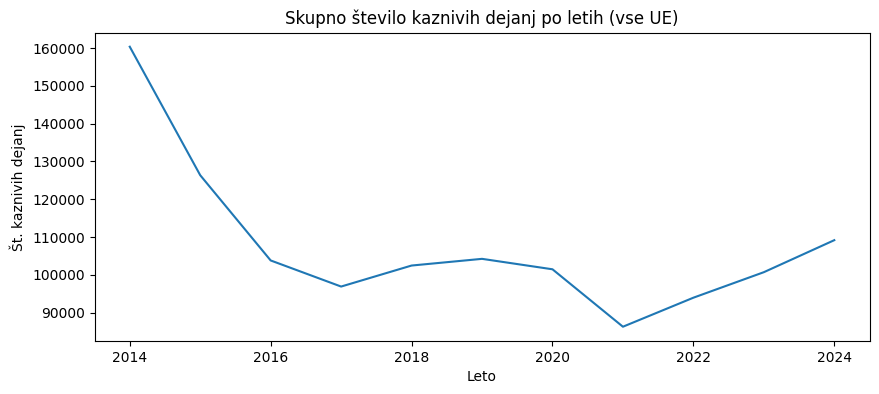

In [66]:
plt.figure(figsize=(10,4))
sns.lineplot(data=df_master, x="leto", y="st_kaznivih_dejanj",
             estimator="sum", errorbar=None)
plt.title("Skupno število kaznivih dejanj po letih (vse UE)")
plt.xlabel("Leto"); plt.ylabel("Št. kaznivih dejanj")
plt.show()

 Po padcu med 2014–2017 sledi nihanje in ponoven dvig po 2021; trend ni strogo monotoni, zato je smiselno modelirati časovni vpliv. Razlog za upad leta 2020 in 2021 poznamo, in sicer je to pandemija covid-19

####Top 10 UE po kaznivih dejanjih na 1000 prebivalcev (zadnje leto)

Da identificiramo najbolj izpostavljene UE na prebivalca

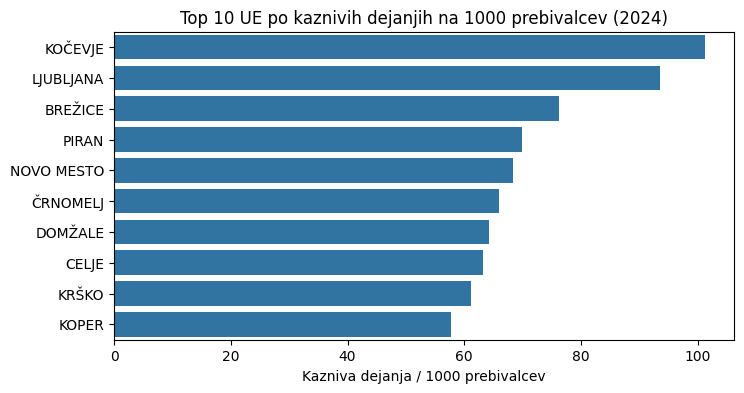

In [67]:
zadnje_leto = df_master["leto"].max()


top_rate = (df_master[df_master.leto == zadnje_leto]
            .sort_values("kriminaliteta_na_1000_preb", ascending=False)
            .head(10))

plt.figure(figsize=(8,4))
sns.barplot(data=top_rate, y="Upravna_enota", x="kriminaliteta_na_1000_preb")


plt.title(f"Top 10 UE po kaznivih dejanjih na 1000 prebivalcev ({zadnje_leto})")
plt.xlabel("Kazniva dejanja / 1000 prebivalcev")
plt.ylabel("")
plt.show()

Nekaj UE močno izstopa (npr. Kočevje, Ljubljana) in je višje od ostalih; problem ni enakomerno porazdeljen.

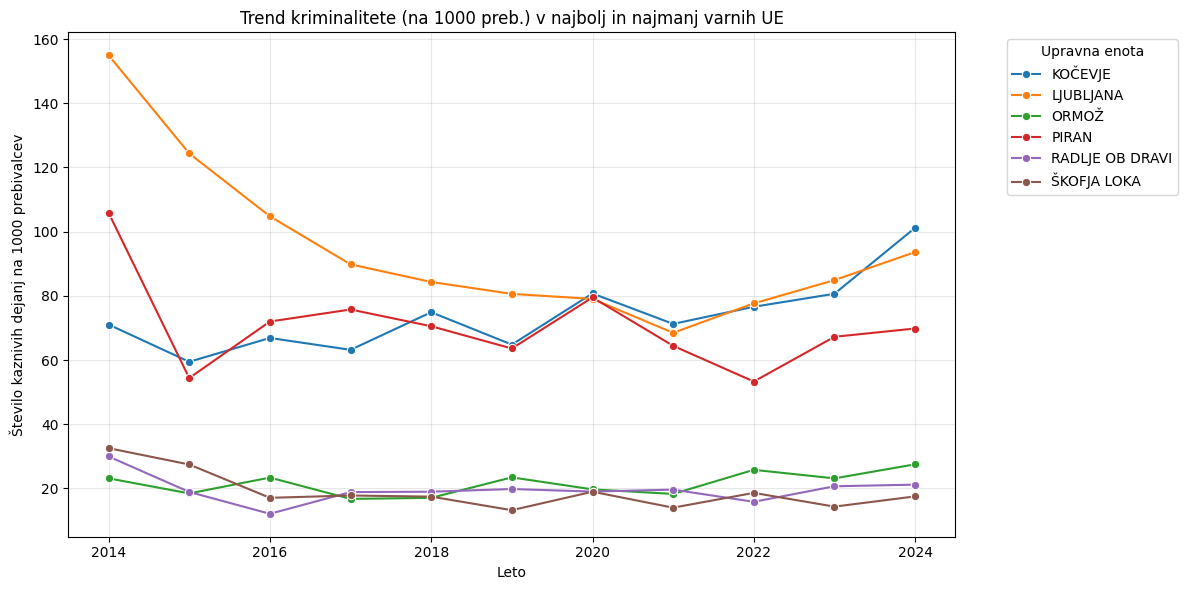

In [68]:
# --- VIZUALIZACIJA ---

# 1. Izračunamo povprečno ogroženost za vsako UE skozi vsa leta
povprecje_kriminalitete = df_master.groupby('Upravna_enota')['kriminaliteta_na_1000_preb'].mean().sort_values()

# 2. Izberemo ekstremne vrednosti: 3 najbolj varne in 3 najbolj nevarne UE
# (To naredi graf pregleden in 'pomenski', kot zahtevajo navodila)
najbolj_varne = povprecje_kriminalitete.head(3).index.tolist()
najbolj_nevarne = povprecje_kriminalitete.tail(3).index.tolist()
izbrane_ue = najbolj_varne + najbolj_nevarne

# 3. Filtriramo glavni dataset, da obdržimo samo te UE
df_plot = df_master[df_master['Upravna_enota'].isin(izbrane_ue)]

# 4. Izris grafa
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_plot, x='leto', y='kriminaliteta_na_1000_preb', hue='Upravna_enota', marker='o')

plt.title('Trend kriminalitete (na 1000 preb.) v najbolj in najmanj varnih UE')
plt.ylabel('Število kaznivih dejanj na 1000 prebivalcev')
plt.xlabel('Leto')
plt.legend(title='Upravna enota', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

TOP 5 UE z največjim trendom rasti kriminalitete (11 let):


,Upravna_enota,Trend_naklon,Skupna_sprememba
1,BREŽICE,2.897181,22.873136
15,KOČEVJE,2.605258,20.345788
30,NOVO MESTO,1.451390,13.951838
26,METLIKA,0.963671,11.119367
31,ORMOŽ,0.486969,3.823601



TOP 5 UE, kjer je varnost najbolj narasla (trend pada):


,Upravna_enota,Trend_naklon,Skupna_sprememba
54,ŠENTJUR PRI CELJU,-2.979226,-24.164068
6,GORNJA RADGONA,-3.579495,-17.048422
51,VRHNIKA,-5.133328,-41.138988
22,LJUBLJANA,-5.398095,-42.638516
11,IZOLA,-6.211980,-50.654162


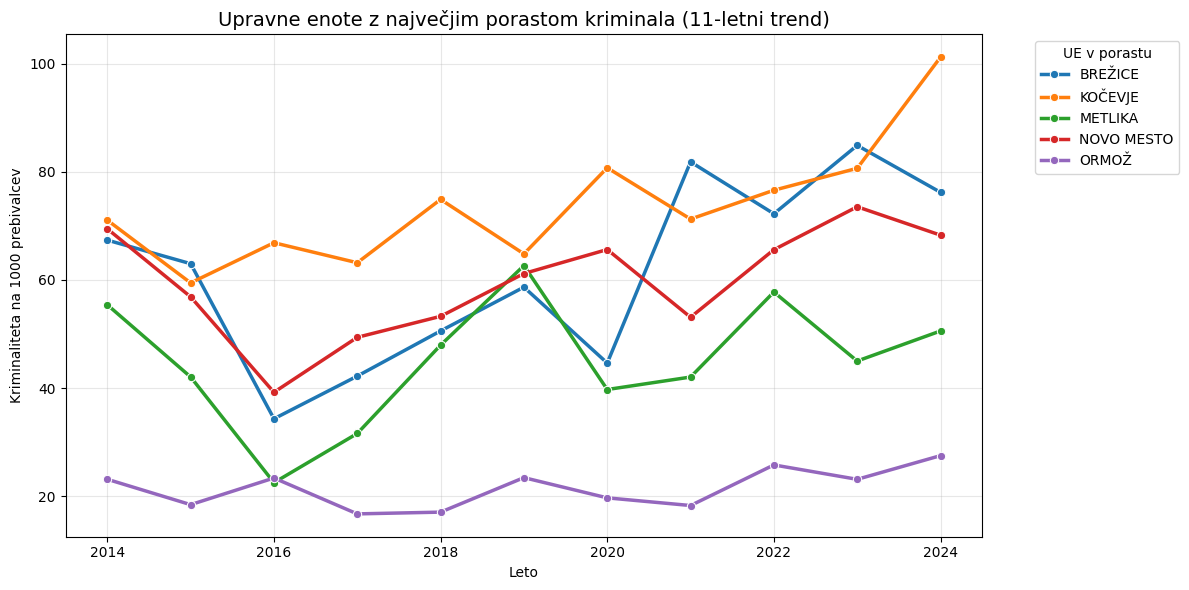

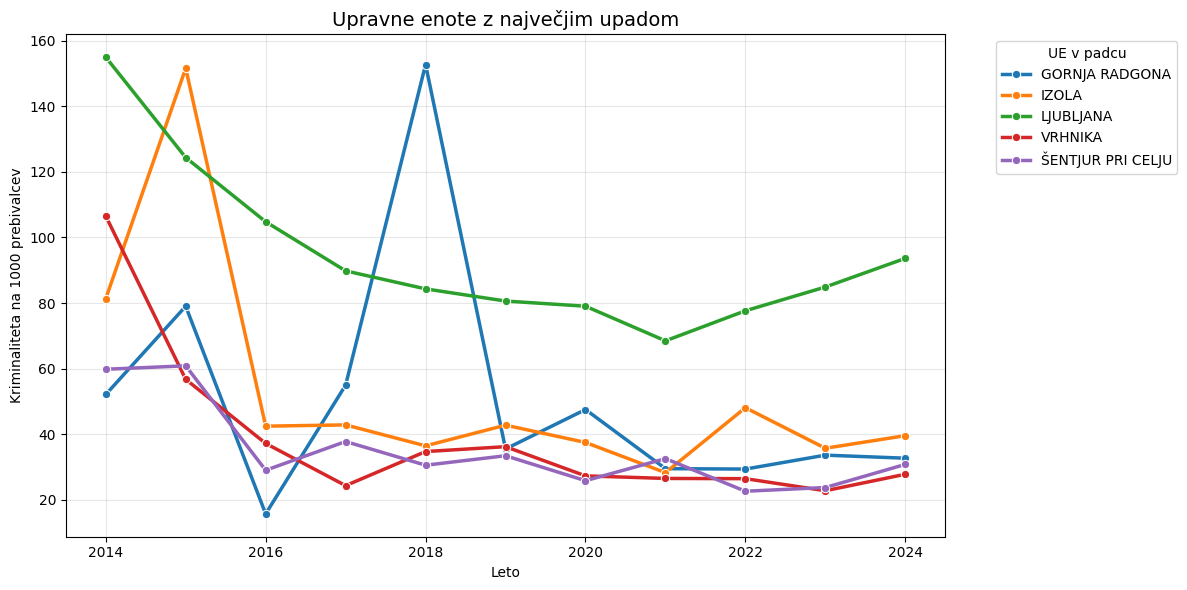

In [69]:
from scipy.stats import linregress

# --- 1. IZRAČUN TRENDA ZA VSAKO UE (VSEH 11 LET) ---

trend_rezultati = []

# Sprehodimo se čez vsako upravno enoto
for ue in df_master['Upravna_enota'].unique():
    # Podatki samo za to UE
    df_ue = df_master[df_master['Upravna_enota'] == ue]

    # Če imamo dovolj podatkov, izračunamo trend
    if len(df_ue) > 1:
        # Linregress vrne 'slope' (naklon).
        # Pozitiven slope = kriminal raste. Negativen slope = kriminal pada.
        slope, intercept, r_value, p_value, std_err = linregress(df_ue['leto'], df_ue['kriminaliteta_na_1000_preb'])

        # Izračunamo še absolutno spremembo (Zadnje povprečje - Prvo povprečje) za lažjo predstavo
        start_avg = df_ue.head(3)['kriminaliteta_na_1000_preb'].mean()
        end_avg = df_ue.tail(3)['kriminaliteta_na_1000_preb'].mean()
        diff = end_avg - start_avg

        trend_rezultati.append({
            'Upravna_enota': ue,
            'Trend_naklon': slope,  # Koliko dejanj več vsako leto
            'Skupna_sprememba': diff # Za koliko se je povečalo v 11 letih
        })

# Pretvorimo v DataFrame in sortiramo po naklonu (padajoče)
df_trend = pd.DataFrame(trend_rezultati).sort_values(by='Trend_naklon', ascending=False)

# --- 2. IZPIS NAJBOLJ KRITIČNIH ---
print("TOP 5 UE z največjim trendom rasti kriminalitete (11 let):")
display(df_trend.head(5))

print("\nTOP 5 UE, kjer je varnost najbolj narasla (trend pada):")
display(df_trend.tail(5))


# --- 3. VIZUALIZACIJA PROBLEMATIČNIH ---
# Vzamemo imena top 5 najslabših
najslabse_ue = df_trend.head(5)['Upravna_enota'].tolist()

# Filtriramo originalne podatke samo za te UE
df_plot_trend = df_master[df_master['Upravna_enota'].isin(najslabse_ue)]


#top 5 najboljsih
najboljse_ue = df_trend.tail(5)['Upravna_enota'].tolist()
df_plot_trend2 = df_master[df_master['Upravna_enota'].isin(najboljse_ue)]


plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_plot_trend,
    x='leto',
    y='kriminaliteta_na_1000_preb',
    hue='Upravna_enota',
    marker='o',
    linewidth=2.5
)

plt.title('Upravne enote z največjim porastom kriminala (11-letni trend)', fontsize=14)
plt.ylabel('Kriminaliteta na 1000 prebivalcev')
plt.xlabel('Leto')
plt.grid(True, alpha=0.3)
plt.legend(title='UE v porastu', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_plot_trend2,
    x='leto',
    y='kriminaliteta_na_1000_preb',
    hue='Upravna_enota',
    marker='o',
    linewidth=2.5
)

plt.title('Upravne enote z največjim upadom', fontsize=14)
plt.ylabel('Kriminaliteta na 1000 prebivalcev')
plt.xlabel('Leto')
plt.grid(True, alpha=0.3)
plt.legend(title='UE v padcu', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


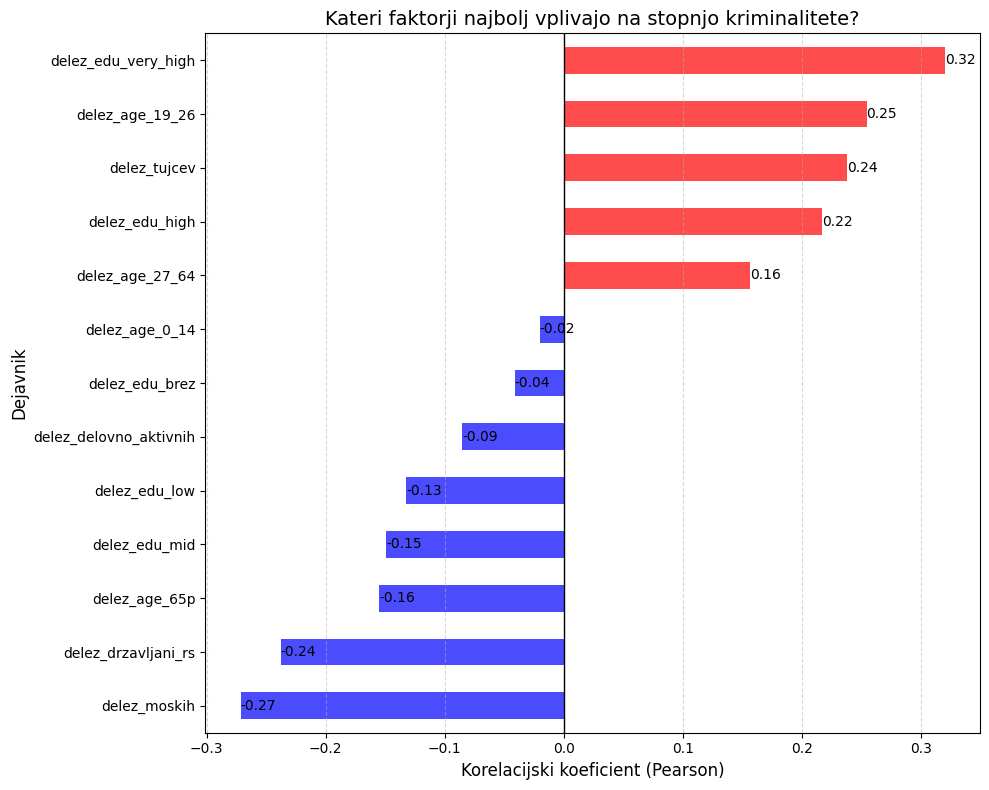

In [70]:
# 1. Izberemo samo tiste stolpce, ki so "deleži" (za pošteno primerjavo)
features_to_analyze = [
    'delez_moskih',
    'delez_tujcev',
    'delez_delovno_aktivnih',
    'delez_drzavljani_rs',
    'delez_edu_low',    # Nizka izobrazba
    'delez_edu_mid',    # Srednja
    'delez_edu_high',   # Visoka
    'delez_edu_brez',   # Brez izobrazbe (tvoja opomba)
    'delez_edu_very_high',
    'delez_age_0_14',
    'delez_age_19_26',
    'delez_age_27_64',
    'delez_age_65p'
]

# 2. Izračunamo korelacijo vsakega faktorja s "kriminaliteta_na_1000_preb"
correlations = df_master[features_to_analyze + ['kriminaliteta_na_1000_preb']].corr()['kriminaliteta_na_1000_preb']

# Odstranimo samo sebe (kriminaliteta vs kriminaliteta je vedno 1)
correlations = correlations.drop('kriminaliteta_na_1000_preb')

# Sortiramo za lepši prikaz
correlations = correlations.sort_values()

# 3. Pripravimo barve (Rdeča = povečuje kriminal, Modra = zmanjšuje)
colors = ['red' if x > 0 else 'blue' for x in correlations]

# 4. Izris grafa
plt.figure(figsize=(10, 8))
# Bar plot
ax = correlations.plot(kind='barh', color=colors, alpha=0.7)

plt.title('Kateri faktorji najbolj vplivajo na stopnjo kriminalitete?', fontsize=14)
plt.xlabel('Korelacijski koeficient (Pearson)', fontsize=12)
plt.ylabel('Dejavnik', fontsize=12)
plt.axvline(0, color='black', linewidth=1) # Črta na sredini
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Dodamo vrednosti na stolpce
for index, value in enumerate(correlations):
    plt.text(value, index, f'{value:.2f}', va='center')

plt.tight_layout()
plt.show()

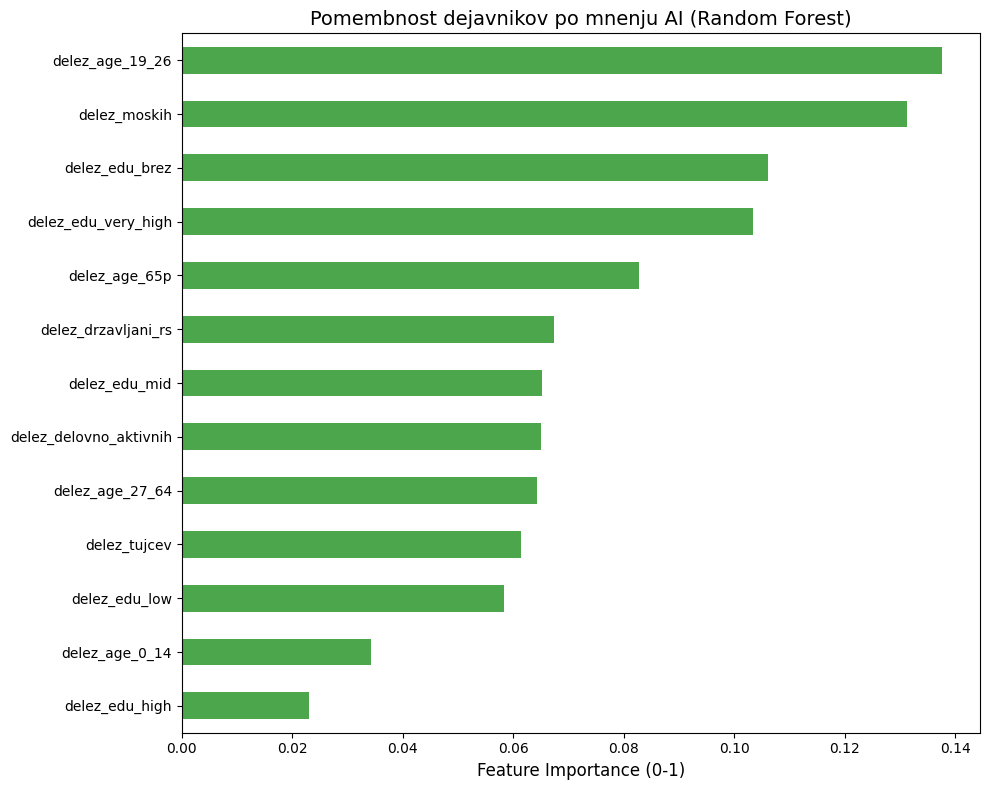

In [71]:
from sklearn.ensemble import RandomForestRegressor

# Priprava podatkov
X = df_master[features_to_analyze].fillna(0) # Features
y = df_master['kriminaliteta_na_1000_preb']  # Target

# Učenje modela
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# Pridobivanje pomembnosti
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

# Izris
plt.figure(figsize=(10, 8))
importances.plot(kind='barh', color='green', alpha=0.7)
plt.title('Pomembnost dejavnikov po mnenju AI (Random Forest)', fontsize=14)
plt.xlabel('Feature Importance (0-1)', fontsize=12)
plt.tight_layout()
plt.show()

# 4. GRUČENJE


Ne želimo jih le razvrstiti od "najbolj varne" do "najmanj varne" (to je sortiranje), ampak želimo najti skupine enot, ki imajo podobne značilnosti.

Da bo gručenje smiselno, moramo izbrati 4 ključne dimenzije, ki definirajo vsako občino:

Varnost: kriminaliteta_na_1000_preb (Glavni faktor).
Demografija: delez_tujcev (Koliko je tujega prebivalstva?).
Ekonomija: delez_delovno_aktivnih (Kako razvita/zaposlena je regija?).
Urbanizacija: Prebivalstvo (Ali gre za velemesto ali podeželje?).
Cilj
Algoritem bo sam ugotovil, da obstajajo npr. 3 naravne skupine:

Gruča A: "Varno podeželje" (Malo ljudi, malo tujcev, malo kriminala).
Gruča B: "Urbana središča" (Veliko ljudi, veliko tujcev, visoka zaposlenost, več kriminala).
Gruča C: "Problematična območja" (Malo zaposlenih, a veliko kriminala).

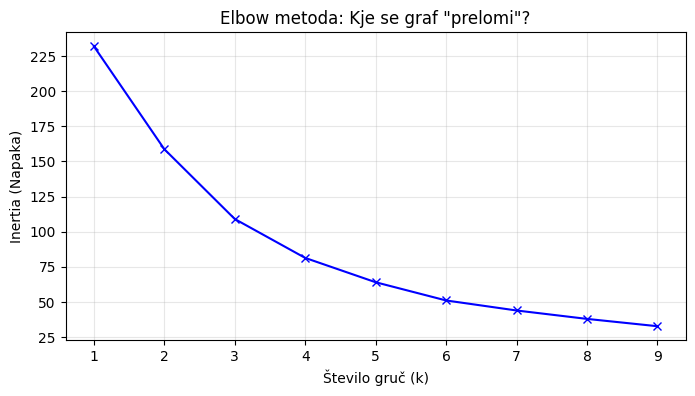

In [72]:
# --- A) PRIPRAVA PODATKOV (Povprečje vseh 11 let) ---
df_clustering = df_master.groupby('Upravna_enota')[[
    'kriminaliteta_na_1000_preb',
    'delez_tujcev',
    'delez_delovno_aktivnih',
    'Prebivalstvo'

]].mean()

# --- B) STANDARDIZACIJA ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clustering)

# --- C) ELBOW METODA ---
inertia = []
range_values = range(1, 10)

for i in range_values:
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Izris grafa
plt.figure(figsize=(8, 4))
plt.plot(range_values, inertia, 'bx-')
plt.xlabel('Število gruč (k)')
plt.ylabel('Inertia (Napaka)')
plt.title('Elbow metoda: Kje se graf "prelomi"?')
plt.grid(True, alpha=0.3)
plt.show()

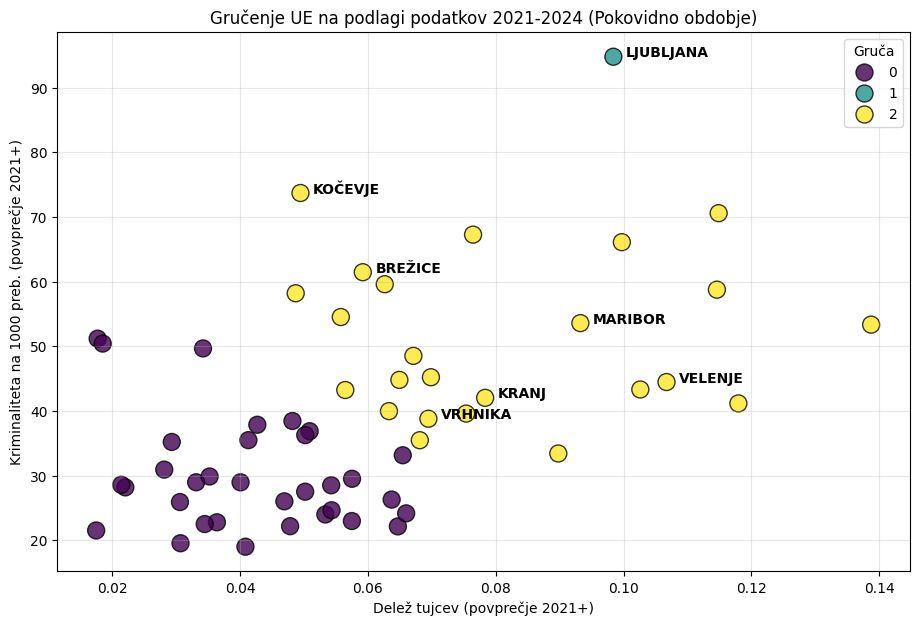

--- PROFILI GRUČ (2021-2024) ---


,kriminaliteta_na_1000_preb,delez_tujcev,delez_delovno_aktivnih,Prebivalstvo
Gruca,,,,
0,29.961475,0.041986,0.392078,23272.721763
2,50.698040,0.080979,0.414670,39785.166667
1,94.762644,0.098408,0.422616,366027.818182


In [73]:
# --- 3. GRUČENJE (K-Means) ---
k = 3  # Predvidevamo 3, glede na prejšnje izkušnje
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

# Dodelimo gruče
df_clustering['Gruca'] = kmeans.fit_predict(X_scaled)

# --- 4. VIZUALIZACIJA (2021+) ---
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df_clustering,
    x='delez_tujcev',
    y='kriminaliteta_na_1000_preb',
    hue='Gruca',
    palette='viridis',
    s=150,
    edgecolor='black',
    alpha=0.8
)

# Označimo ključne igralce, da vidimo premike
kljucne_ue = ['LJUBLJANA', 'KOČEVJE', 'MARIBOR', 'KRANJ', 'VELENJE', 'BREŽICE', 'VRHNIKA']

for ue in kljucne_ue:
    if ue in df_clustering.index:
        plt.text(
            df_clustering.loc[ue, 'delez_tujcev'] + 0.002,
            df_clustering.loc[ue, 'kriminaliteta_na_1000_preb'],
            ue,
            fontsize=10,
            fontweight='bold',
            color='black' # Ali rdeča za poudarek
        )

plt.title('Gručenje UE na podlagi podatkov 2021-2024 (Pokovidno obdobje)')
plt.xlabel('Delež tujcev (povprečje 2021+)')
plt.ylabel('Kriminaliteta na 1000 preb. (povprečje 2021+)')
plt.grid(True, alpha=0.3)
plt.legend(title='Gruča')
plt.show()

# --- 5. INTERPRETACIJA ---
print("--- PROFILI GRUČ (2021-2024) ---")
recent_profile = df_clustering.groupby('Gruca').mean().sort_values('kriminaliteta_na_1000_preb')
display(recent_profile)



Ta graf je "zlati rudnik" informacij. Algoritem je razdelil Slovenijo na tri zelo logične dele:

GRUČA 1 (Turkizna pika - zgoraj desno): Samo Ljubljana.

Pomen: Ljubljana je kategorija zase. Je edina, ki je "velemesto" (po slovenskih standardih), ima ogromno tujcev in izjemno visoko stopnjo kriminala (nad 90/1000 preb.).
Zaključek: Nobena druga občina se ne more primerjati z dinamiko glavnega mesta.
GRUČA 2 (Rumene pike - desna stran): Urbana in industrijska središča.

Kdo je tu: Maribor, Celje, Koper, Kranj, pa tudi Kočevje in Brežice.
Značilnost: To so občine, ki imajo visok delež tujcev (desno na X osi) in povišano stopnjo kriminala (višje na Y osi).
Posebnost Kočevja: Poglej, kje leži Kočevje! Ima manj tujcev kot Koper ali Kranj (je bolj levo), ampak ima višji kriminal (je višje). To je "anomalija" – visoka nevarnost kljub manjšemu številu tujcev v primerjavi z drugimi urbanimi centri.
GRUČA 0 (Vijolične pike - levo spodaj): Varna Slovenija.

Kdo je tu: Večina manjših upravnih enot.
Značilnost: Malo tujcev (levo) in nizek kriminal (spodaj). To je "mirno podeželje".

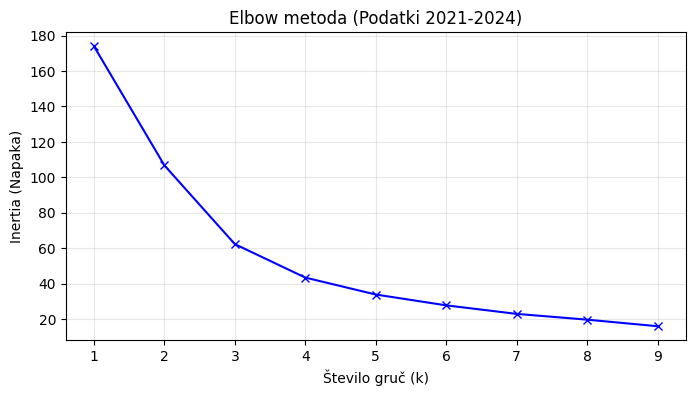

In [74]:
# --- 1. PRIPRAVA PODATKOV (Samo 2021 naprej) ---
# Filtriramo originalni dataframe
df_recent = df_master[df_master['leto'] >= 2021].copy()

# Izračunamo povprečje po UE samo za ta leta
# Uporabljamo isto "zmagovalno" kombinacijo 3 spremenljivk
df_clustering_recent = df_recent.groupby('Upravna_enota')[[
    'kriminaliteta_na_1000_preb',
    'delez_tujcev',
    'Prebivalstvo'
]].mean()

# Standardizacija
scaler_recent = StandardScaler()
X_recent_scaled = scaler_recent.fit_transform(df_clustering_recent)

# --- 2. ELBOW METODA (Za obdobje 2021+) ---
inertia = []
range_values = range(1, 10)

for i in range_values:
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_recent_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range_values, inertia, 'bx-')
plt.xlabel('Število gruč (k)')
plt.ylabel('Inertia (Napaka)')
plt.title('Elbow metoda (Podatki 2021-2024)')
plt.grid(True, alpha=0.3)
plt.show()

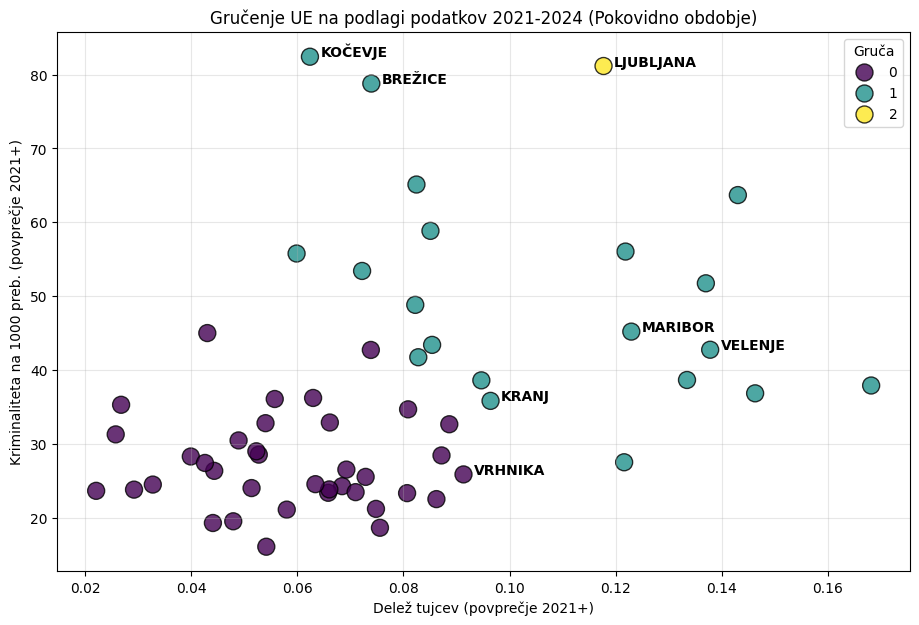

--- PROFILI GRUČ (2021-2024) ---


,kriminaliteta_na_1000_preb,delez_tujcev,Prebivalstvo
Gruca,,,
0,27.407156,0.058653,23227.885135
1,50.162813,0.105484,44200.212500
2,81.151464,0.117725,372314.000000


In [75]:
# --- 3. GRUČENJE (K-Means) ---
k = 3  # Predvidevamo 3, glede na prejšnje izkušnje
kmeans_recent = KMeans(n_clusters=k, random_state=42, n_init=10)

# Dodelimo gruče
df_clustering_recent['Gruca'] = kmeans_recent.fit_predict(X_recent_scaled)

# --- 4. VIZUALIZACIJA (2021+) ---
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df_clustering_recent,
    x='delez_tujcev',
    y='kriminaliteta_na_1000_preb',
    hue='Gruca',
    palette='viridis',
    s=150,
    edgecolor='black',
    alpha=0.8
)

# Označimo ključne igralce, da vidimo premike
kljucne_ue = ['LJUBLJANA', 'KOČEVJE', 'MARIBOR', 'KRANJ', 'VELENJE', 'BREŽICE', 'VRHNIKA']

for ue in kljucne_ue:
    if ue in df_clustering_recent.index:
        plt.text(
            df_clustering_recent.loc[ue, 'delez_tujcev'] + 0.002,
            df_clustering_recent.loc[ue, 'kriminaliteta_na_1000_preb'],
            ue,
            fontsize=10,
            fontweight='bold',
            color='black' # Ali rdeča za poudarek
        )

plt.title('Gručenje UE na podlagi podatkov 2021-2024 (Pokovidno obdobje)')
plt.xlabel('Delež tujcev (povprečje 2021+)')
plt.ylabel('Kriminaliteta na 1000 preb. (povprečje 2021+)')
plt.grid(True, alpha=0.3)
plt.legend(title='Gruča')
plt.show()

# --- 5. INTERPRETACIJA ---
print("--- PROFILI GRUČ (2021-2024) ---")
recent_profile = df_clustering_recent.groupby('Gruca').mean().sort_values('kriminaliteta_na_1000_preb')
display(recent_profile)



Ta graf ti pove, kako nastaviti algoritem za analizo novejše dobe.
Prelom (komolec): Jasno se vidi pri k=3 (in morda še en manjši pri k=4).
Pomen: Tudi če gledamo samo zadnja leta (po COVID-u), se struktura Slovenije ni bistveno spremenila. Še vedno obstajajo 3 naravne skupine.

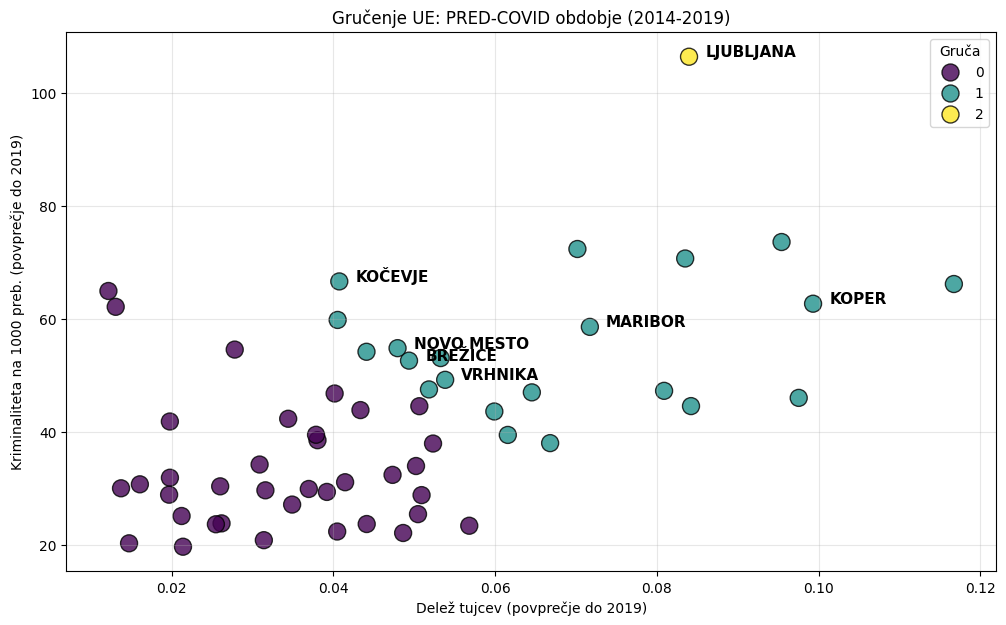

--- ANALIZA SPREMEMBE: KOČEVJE ---
Kriminaliteta PRED Covidom (2014-2019): 66.7 na 1000 preb.
(Primerjaj to številko s tisto na prejšnjem grafu, ki je bila verjetno okoli 80+!)


In [76]:
# --- ANALIZA PRED-COVID OBDOBJA (2014 - 2019) ---

# 1. PRIPRAVA PODATKOV (Samo leta pred 2020)
df_pre = df_master[df_master['leto'] < 2020].copy()

# Enaka agregacija kot prej
df_clustering_pre = df_pre.groupby('Upravna_enota')[[
    'kriminaliteta_na_1000_preb',
    'delez_tujcev',
    'Prebivalstvo'
]].mean()

# 2. GRUČENJE (K-Means, k=3)
# Standardizacija
scaler_pre = StandardScaler()
X_pre_scaled = scaler_pre.fit_transform(df_clustering_pre)

# Model
kmeans_pre = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clustering_pre['Gruca'] = kmeans_pre.fit_predict(X_pre_scaled)

# 3. VIZUALIZACIJA
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df_clustering_pre,
    x='delez_tujcev',
    y='kriminaliteta_na_1000_preb',
    hue='Gruca',
    palette='viridis',
    s=150,
    edgecolor='black',
    alpha=0.8
)

# Označimo iste ključne igralce za primerjavo
kljucna_mesta = ['LJUBLJANA', 'KOČEVJE', 'MARIBOR', 'BREŽICE', 'NOVO MESTO', 'KOPER', 'VRHNIKA']
for ime in kljucna_mesta:
    if ime in df_clustering_pre.index:
        plt.text(
            df_clustering_pre.loc[ime, 'delez_tujcev'] + 0.002,
            df_clustering_pre.loc[ime, 'kriminaliteta_na_1000_preb'],
            ime,
            fontsize=11,
            fontweight='bold'
        )

plt.title('Gručenje UE: PRED-COVID obdobje (2014-2019)')
plt.xlabel('Delež tujcev (povprečje do 2019)')
plt.ylabel('Kriminaliteta na 1000 preb. (povprečje do 2019)')
plt.grid(True, alpha=0.3)
plt.legend(title='Gruča')
plt.show()

# 4. IZPIS RAZLIKE ZA KOČEVJE (Prej vs. Potem)
krim_prej = df_clustering_pre.loc['KOČEVJE', 'kriminaliteta_na_1000_preb']
# (Predpostavljam, da imaš še vedno df_clustering_recent iz prejšnjega koraka v spominu)
# Če si vmes resetiral, samo poglej graf.
print(f"--- ANALIZA SPREMEMBE: KOČEVJE ---")
print(f"Kriminaliteta PRED Covidom (2014-2019): {krim_prej:.1f} na 1000 preb.")
print("(Primerjaj to številko s tisto na prejšnjem grafu, ki je bila verjetno okoli 80+!)")

In [77]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Funkcija, ki naredi gručenje in UREDI gruče po nevarnosti (0=Varna, 2=Nevarna)
def get_sorted_clusters(df_subset, leta_opis):
    # 1. Agregacija
    df_agg = df_subset.groupby('Upravna_enota')[[
        'kriminaliteta_na_1000_preb',
        'delez_tujcev',
        'Prebivalstvo'
    ]].mean()

    # 2. Standardizacija
    scaler = StandardScaler()
    X = scaler.fit_transform(df_agg)

    # 3. K-Means
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    df_agg['Gruca_Raw'] = labels

    # 4. PREIMENOVANJE GRUČ (0=Najmanj kriminala, 2=Največ)
    # Izračunamo povprečni kriminal za vsako "surovo" gručo
    cluster_means = df_agg.groupby('Gruca_Raw')['kriminaliteta_na_1000_preb'].mean().sort_values()

    # Ustvarimo mapiranje: Indeks 0 v sortiranem seznamu dobi ime 0 (Varna), itd.
    mapping = {original_id: new_id for new_id, original_id in enumerate(cluster_means.index)}

    df_agg[f'Gruca_{leta_opis}'] = df_agg['Gruca_Raw'].map(mapping)

    # Vrnemo samo ime gruče in kriminaliteto za kontrolo
    return df_agg[[f'Gruca_{leta_opis}', 'kriminaliteta_na_1000_preb']]

# --- 1. IZVEDBA ZA OBA OBDOBJA ---
# Obdobje 1: PREJ (2014-2019)
df_prej = df_master[df_master['leto'] < 2020]
rezultati_prej = get_sorted_clusters(df_prej, 'PREJ')

# Obdobje 2: ZDAJ (2021-2024)
df_potem = df_master[df_master['leto'] >= 2021]
rezultati_potem = get_sorted_clusters(df_potem, 'POTEM')

# --- 2. ZDRUŽITEV IN PRIMERJAVA ---
# Združimo tabeli
primerjava = pd.merge(rezultati_prej, rezultati_potem, on='Upravna_enota', suffixes=('_old', '_new'))

# Izračunamo razliko (Če je > 0, se je poslabšalo. Če je < 0, se je izboljšalo)
primerjava['Sprememba_Gruce'] = primerjava['Gruca_POTEM'] - primerjava['Gruca_PREJ']

# --- 3. FILTRIRANJE TISTIH, KI SO ZAMENJALI SKUPINO ---
spremembe = primerjava[primerjava['Sprememba_Gruce'] != 0].copy()

# Dodamo opise za lepši izpis
def opis_spremembe(row):
    stara = int(row['Gruca_PREJ'])
    nova = int(row['Gruca_POTEM'])
    if nova > stara:
        return f"🔴 POSLABŠANJE ({stara} -> {nova})"
    else:
        return f"🟢 IZBOLJŠANJE ({stara} -> {nova})"

spremembe['Tip_Spremembe'] = spremembe.apply(opis_spremembe, axis=1)

# Sortiramo: Najprej tiste, ki so se najbolj poslabšale
spremembe = spremembe.sort_values('Sprememba_Gruce', ascending=False)

# --- 4. IZPIS REZULTATOV ---
print(f"LEGENDA GRUČ: 0 = Varna/Mirna, 1 = Srednja, 2 = Nevarna/Urbana")
print("-" * 60)
print(f"Najdenih je {len(spremembe)} upravnih enot, ki so zamenjale profil.")

# Izpis samo relevantnih stolpcev
cols_to_show = ['Tip_Spremembe', 'kriminaliteta_na_1000_preb_old', 'kriminaliteta_na_1000_preb_new']
display(spremembe[cols_to_show])

LEGENDA GRUČ: 0 = Varna/Mirna, 1 = Srednja, 2 = Nevarna/Urbana
------------------------------------------------------------
Najdenih je 1 upravnih enot, ki so zamenjale profil.


,Tip_Spremembe,kriminaliteta_na_1000_preb_old,kriminaliteta_na_1000_preb_new
Upravna_enota,,,
VRHNIKA,🟢 IZBOLJŠANJE (1 -> 0),49.288113,25.891016


# 5. KLASIFIKACIJA

## 5. 1. KLASIFIKACIJA V TRI SKUPINE

Vsi stolpci so pripravljeni!

TOČNOST MODELA: 63.5%
(Naključno ugibanje bi bilo 33.3%)

--- POROČILO KLASIFIKACIJE ---
              precision    recall  f1-score   support

       Varna       0.61      0.70      0.65        56
     Srednja       0.55      0.55      0.55        65
     Nevarna       0.76      0.66      0.71        71

    accuracy                           0.64       192
   macro avg       0.64      0.64      0.64       192
weighted avg       0.64      0.64      0.64       192



/tmp/ipython-input-1162863067.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp.values, y=imp.index, palette='magma')


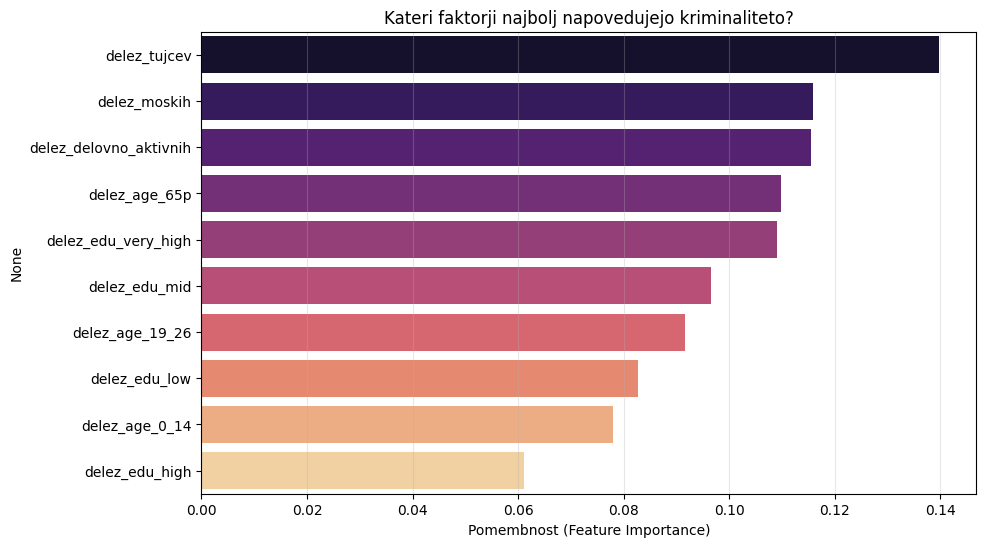

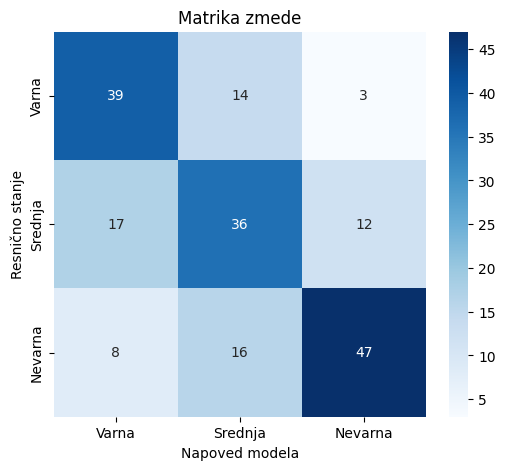

In [81]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. IZBOR NOVIH ZNAČILK ---
# Iz tvojega seznama sem izbral tiste, ki niso med seboj podvojene (npr. ne rabiš tujcev in državljanov hkrati)
features = [
    'delez_tujcev',             # Ključni demografski faktor
    'delez_delovno_aktivnih',   # Ekonomski status
    'delez_moskih',            # Spolna struktura (včasih vpliva)
    'delez_edu_low',            # Nizka izobrazba (socialni status)
    'delez_edu_mid',
    'delez_edu_high',           # Visoka izobrazba
    'delez_edu_very_high',
    'delez_age_19_26',          # "Riskantna" skupina (mladi odrasli)
    'delez_age_65p',            # Starejše prebivalstvo (ponavadi bolj varno)
    'delez_age_0_14'            # Družinsko okolje
]

# Preverimo, če vsi stolpci obstajajo (za vsak slučaj)
missing_cols = [col for col in features if col not in df_master.columns]
if missing_cols:
    print(f"OPOZORILO: Manjkajo stolpci: {missing_cols}")
else:
    print("Vsi stolpci so pripravljeni!")

# --- 2. PRIPRAVA CILJNE SPREMENLJIVKE (TARGET) ---
# Razdelimo v 3 razrede glede na kvantile (33% / 33% / 33%)
q1 = df_master['kriminaliteta_na_1000_preb'].quantile(0.33)
q2 = df_master['kriminaliteta_na_1000_preb'].quantile(0.66)

def doloci_razred(x):
    if x <= q1: return 0      # VARNA
    elif x <= q2: return 1    # SREDNJA
    else: return 2            # NEVARNA

df_master['Target'] = df_master['kriminaliteta_na_1000_preb'].apply(doloci_razred)

# Priprava X in y
X = df_master[features].fillna(0)
y = df_master['Target']

# Razdelitev (70% učenje, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# --- 3. UČENJE MODELA ---
# Povečal sem n_estimators in nastavil max_depth, da preprečim "biflanje" (overfitting)
rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
rf.fit(X_train, y_train)

# --- 4. REZULTATI ---
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"\nTOČNOST MODELA: {acc:.1%}")
print(f"(Naključno ugibanje bi bilo 33.3%)")

print("\n--- POROČILO KLASIFIKACIJE ---")
print(classification_report(y_test, y_pred, target_names=['Varna', 'Srednja', 'Nevarna']))

# --- 5. KAJ JE NAJBOLJ POMEMBNO? (Feature Importance) ---
imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=imp.values, y=imp.index, palette='magma')
plt.title('Kateri faktorji najbolj napovedujejo kriminaliteto?')
plt.xlabel('Pomembnost (Feature Importance)')
plt.grid(axis='x', alpha=0.3)
plt.show()

# --- 6. PREVERJANJE NAPAK (Confusion Matrix) ---
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Varna', 'Srednja', 'Nevarna'],
            yticklabels=['Varna', 'Srednja', 'Nevarna'])
plt.ylabel('Resnično stanje')
plt.xlabel('Napoved modela')
plt.title('Matrika zmede')
plt.show()

In [83]:
# --- 1. RAZDELITEV PODATKOV NA PRETEKLOST (UČENJE) IN SEDANJOST (TEST 2024) ---

# Določimo meje razredov na podlagi ZGODOVINE (do 2023)
# To je pomembno! Ne smemo gledati prihodnosti, da določimo, kaj je "varno".
df_history = df_master[df_master['leto'] < 2024].copy()
df_2024 = df_master[df_master['leto'] == 2024].copy()

q1 = df_history['kriminaliteta_na_1000_preb'].quantile(0.33)
q2 = df_history['kriminaliteta_na_1000_preb'].quantile(0.66)

print(f"Meje (na podlagi zgodovine): Varna < {q1:.1f} | Nevarna > {q2:.1f}")

# Funkcija za določanje razredov
def doloci_razred(x):
    if x <= q1: return 0      # VARNA
    elif x <= q2: return 1    # SREDNJA
    else: return 2            # NEVARNA

# Dodelimo razrede obema tabelama
df_history['Target'] = df_history['kriminaliteta_na_1000_preb'].apply(doloci_razred)
df_2024['Target'] = df_2024['kriminaliteta_na_1000_preb'].apply(doloci_razred)

# --- 2. PRIPRAVA ZNAČILK (Iste kot prej) ---
features = [
    'delez_tujcev', 'delez_delovno_aktivnih', 'delez_moskih',
    'delez_edu_low', 'delez_edu_mid', 'delez_edu_high', 'delez_edu_very_high',
    'delez_age_19_26', 'delez_age_65p', 'delez_age_0_14'
]

X_train = df_history[features].fillna(0)
y_train = df_history['Target']

X_2024 = df_2024[features].fillna(0)
y_2024 = df_2024['Target']

# --- 3. UČENJE MODELA NA ZGODOVINI ---
rf_time = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
rf_time.fit(X_train, y_train)

# --- 4. NAPOVEDOVANJE ZA 2024 ---
y_pred_2024 = rf_time.predict(X_2024)
acc_2024 = accuracy_score(y_2024, y_pred_2024)

print(f"\nTOČNOST NAPOVEDI ZA LETO 2024: {acc_2024:.1%}")

# --- 5. ANALIZA REZULTATOV (Kje je zadel, kje zgrešil?) ---
# Ustvarimo pregledno tabelo rezultatov
rezultati = df_2024[['Upravna_enota', 'kriminaliteta_na_1000_preb']].copy()
rezultati['Dejansko_2024'] = y_2024
rezultati['Napoved_Model'] = y_pred_2024

# Mapiranje številk v besede za lepši izpis
ime_razreda = {0: '🟢 Varna', 1: '🟡 Srednja', 2: '🔴 Nevarna'}
rezultati['Dejansko_Opis'] = rezultati['Dejansko_2024'].map(ime_razreda)
rezultati['Napoved_Opis'] = rezultati['Napoved_Model'].map(ime_razreda)

# Iščemo napake (kjer se napoved razlikuje od dejanskega)
napake = rezultati[rezultati['Dejansko_2024'] != rezultati['Napoved_Model']].copy()

print(f"\nModel je pravilno napovedal {len(rezultati) - len(napake)} od {len(rezultati)} občin.")
print("\n--- ZANIMIVI KIKS-I (Kjer nas je 2024 presenetilo) ---")
# Prikaz tistih, kjer je dejansko stanje SLABŠE od napovedi (Model rekel Varno, bilo je Nevarno)
negativna_presenecenja = napake[napake['Dejansko_2024'] > napake['Napoved_Model']]
display(negativna_presenecenja[['Upravna_enota', 'kriminaliteta_na_1000_preb', 'Napoved_Opis', 'Dejansko_Opis']])

print("\n--- KLJUČNA MESTA (Preverimo naše znance) ---")
kljucna = ['LJUBLJANA', 'KOČEVJE', 'BREŽICE', 'MARIBOR', 'KOPER', 'VELENJE', 'VRHNIKA']
display(rezultati[rezultati['Upravna_enota'].isin(kljucna)][['Upravna_enota', 'Napoved_Opis', 'Dejansko_Opis']])

Meje (na podlagi zgodovine): Varna < 28.5 | Nevarna > 41.7

TOČNOST NAPOVEDI ZA LETO 2024: 69.0%

Model je pravilno napovedal 40 od 58 občin.

--- ZANIMIVI KIKS-I (Kjer nas je 2024 presenetilo) ---


,Upravna_enota,kriminaliteta_na_1000_preb,Napoved_Opis,Dejansko_Opis
596,KRANJ,52.142415,🟡 Srednja,🔴 Nevarna
600,LENDAVA,44.514307,🟡 Srednja,🔴 Nevarna
601,LITIJA,30.779185,🟢 Varna,🟡 Srednja
609,NOVA GORICA,42.637784,🟡 Srednja,🔴 Nevarna
619,RIBNICA,36.405168,🟢 Varna,🟡 Srednja
620,RUŠE,32.457284,🟢 Varna,🟡 Srednja
623,SLOVENJ GRADEC,40.120176,🟢 Varna,🟡 Srednja
625,SLOVENSKE KONJICE,33.145998,🟢 Varna,🟡 Srednja
628,TREBNJE,48.448751,🟡 Srednja,🔴 Nevarna
630,VELENJE,46.489564,🟡 Srednja,🔴 Nevarna



--- KLJUČNA MESTA (Preverimo naše znance) ---


,Upravna_enota,Napoved_Opis,Dejansko_Opis
581,BREŽICE,🔴 Nevarna,🔴 Nevarna
594,KOPER,🔴 Nevarna,🔴 Nevarna
595,KOČEVJE,🔴 Nevarna,🔴 Nevarna
602,LJUBLJANA,🔴 Nevarna,🔴 Nevarna
605,MARIBOR,🔴 Nevarna,🔴 Nevarna
630,VELENJE,🟡 Srednja,🔴 Nevarna
631,VRHNIKA,🟢 Varna,🟢 Varna


"Naš model je dosegel visoko, 69-odstotno natančnost pri napovedi varnosti za leto 2024 zgolj na podlagi preteklih demografskih trendov.

Še bolj zgovorna pa je analiza napak: Model je bil v letu 2024 sistematično preveč optimističen. V kar 12 primerih je napovedal nižjo stopnjo nevarnosti, kot se je dejansko zgodila (npr. Kranj, Velenje, Trebnje).

Zaključek: Leto 2024 predstavlja prelomnico, kjer se je varnostna situacija v številnih občinah (Trebnje, Ribnica, Kranj) poslabšala hitreje, kot bi lahko sklepali zgolj iz sprememb v prebivalstvu. To nakazuje na zunanje dejavnike ali širjenje kriminalnih žarišč izven tradicionalnih con."

--- XGBOOST REZULTAT (3 SKUPINE) ---
Točnost napovedi za 2024: 65.5%
(Random Forest je bil okoli 62-69%)

--- PODROBNO POROČILO ---
              precision    recall  f1-score   support

       Varna       0.64      0.67      0.65        21
     Srednja       0.53      0.56      0.54        18
     Nevarna       0.82      0.74      0.78        19

    accuracy                           0.66        58
   macro avg       0.66      0.65      0.66        58
weighted avg       0.66      0.66      0.66        58



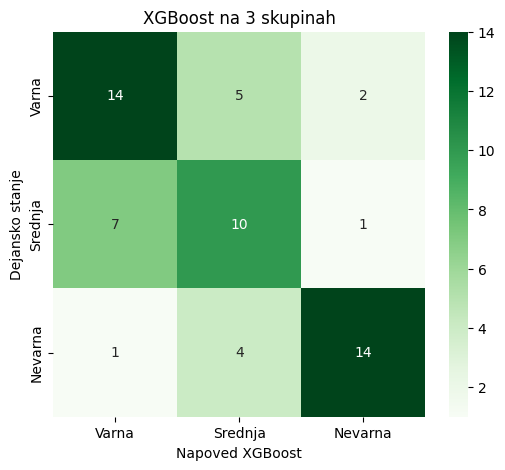

In [95]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. PRIPRAVA PODATKOV (3 SKUPINE) ---
# Učenje na zgodovini (do 2023), test na 2024
df_history = df_master[df_master['leto'] < 2024].copy()
df_2024 = df_master[df_master['leto'] == 2024].copy()

# Določimo meje (kvantili) na zgodovini
q1 = df_history['kriminaliteta_na_1000_preb'].quantile(0.33)
q2 = df_history['kriminaliteta_na_1000_preb'].quantile(0.66)

def doloci_razred_3(x):
    if x <= q1: return 0      # VARNA
    elif x <= q2: return 1    # SREDNJA
    else: return 2            # NEVARNA

# Ciljna spremenljivka (0, 1, 2)
y_train = df_history['kriminaliteta_na_1000_preb'].apply(doloci_razred_3)
y_test = df_2024['kriminaliteta_na_1000_preb'].apply(doloci_razred_3)

# Značilke (Iste kot prej)
features = [
    'delez_tujcev', 'delez_delovno_aktivnih', 'delez_moskih',
    'delez_edu_low', 'delez_edu_high', 'delez_edu_very_high',
    'delez_age_19_26', 'delez_age_65p', 'delez_age_0_14'
]

X_train = df_history[features].fillna(0)
X_test = df_2024[features].fillna(0)

# --- 2. UČENJE XGBOOST MODELA ---
# Nastavitve za večrazredno klasifikacijo (multi:softmax)
xgb_3 = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,  # Manjši learning rate za večjo natančnost
    max_depth=6,         # Malo globlja drevesa
    objective='multi:softmax',
    num_class=3,
    random_state=42
)

xgb_3.fit(X_train, y_train)

# --- 3. REZULTATI ---
y_pred = xgb_3.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"--- XGBOOST REZULTAT (3 SKUPINE) ---")
print(f"Točnost napovedi za 2024: {acc:.1%}")
print(f"(Random Forest je bil okoli 62-69%)")

print("\n--- PODROBNO POROČILO ---")
print(classification_report(y_test, y_pred, target_names=['Varna', 'Srednja', 'Nevarna']))

# --- 4. CONFUSION MATRIX ---
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Varna', 'Srednja', 'Nevarna'],
            yticklabels=['Varna', 'Srednja', 'Nevarna'])
plt.xlabel('Napoved XGBoost')
plt.ylabel('Dejansko stanje')
plt.title('XGBoost na 3 skupinah')
plt.show()

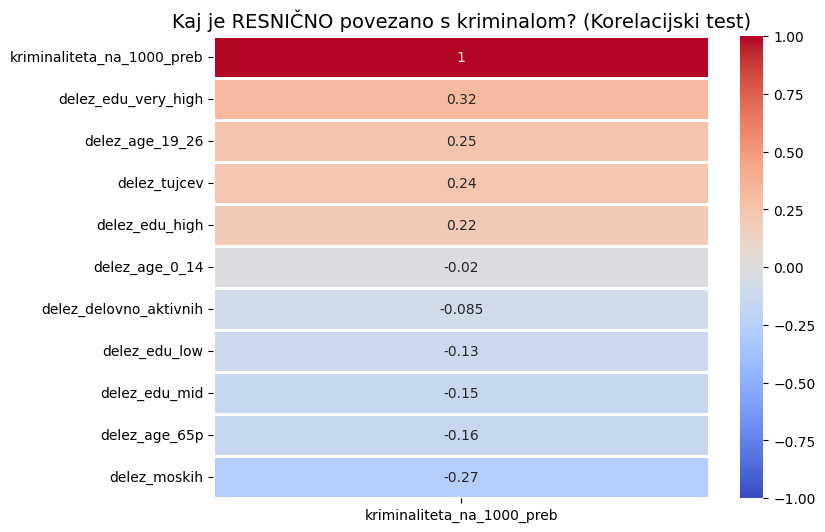

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt

# Izberemo faktorje za primerjavo mitov
faktorji_za_primerjavo = [
    'kriminaliteta_na_1000_preb',
    'delez_tujcev',             # Ključni demografski faktor
    'delez_delovno_aktivnih',   # Ekonomski status
    'delez_moskih',            # Spolna struktura (včasih vpliva)
    'delez_edu_low',            # Nizka izobrazba (socialni status)
    'delez_edu_mid',
    'delez_edu_high',           # Visoka izobrazba
    'delez_edu_very_high',
    'delez_age_19_26',          # "Riskantna" skupina (mladi odrasli)
    'delez_age_65p',            # Starejše prebivalstvo (ponavadi bolj varno)
    'delez_age_0_14'                 # Urbanizacija
]

# Izračunamo korelacijo
corr_matrix = df_master[faktorji_za_primerjavo].corr()

# Fokusiramo se samo na prvi stolpec (povezava s kriminalom)
kriminal_corr = corr_matrix[['kriminaliteta_na_1000_preb']].sort_values(by='kriminaliteta_na_1000_preb', ascending=False)

# Vizualizacija
plt.figure(figsize=(8, 6))
sns.heatmap(kriminal_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=1)
plt.title('Kaj je RESNIČNO povezano s kriminalom? (Korelacijski test)', fontsize=14)
plt.show()

In [89]:
# Izberemo zadnje razpoložljivo leto (2024), da bo slika aktualna
df_check = df_master[df_master['leto'] == 2024].copy()

# Razvrstimo po deležu zelo visoke izobrazbe (padajoče)
# Če imata dve UE enak delež, odloča velikost prebivalstva
df_sorted = df_check.sort_values(
    by=['delez_edu_very_high', 'Prebivalstvo'],
    ascending=[False, False]
)[['Upravna_enota', 'delez_edu_very_high', 'kriminaliteta_na_1000_preb', 'Prebivalstvo']]

# Prikaz prvih 15 mest
print("--- TOP 15 OBČIN PO DELEŽU ZELO VISOKE IZOBRAZBE (2024) ---")
display(df_sorted.head(15))

# Prikaz zadnjih 15 mest (za kontrast)
print("\n--- OBČINE Z NAJNIŽJIM DELEŽEM ZELO VISOKE IZOBRAZBE ---")
display(df_sorted.tail(15))

--- TOP 15 OBČIN PO DELEŽU ZELO VISOKE IZOBRAZBE (2024) ---


,Upravna_enota,delez_edu_very_high,kriminaliteta_na_1000_preb,Prebivalstvo
602,LJUBLJANA,0.037464,93.617837,375719.0
631,VRHNIKA,0.021573,27.805770,26793.0
584,DOMŽALE,0.021173,64.285714,62580.0
605,MARIBOR,0.019804,48.896824,151789.0
617,RADOVLJICA,0.019503,39.373186,35481.0
613,PIRAN,0.019126,69.813720,18091.0
604,LOGATEC,0.018711,38.420562,15018.0
596,KRANJ,0.018135,52.142415,83924.0
591,IZOLA,0.017235,39.567909,16478.0
593,KAMNIK,0.016875,35.895764,36801.0



--- OBČINE Z NAJNIŽJIM DELEŽEM ZELO VISOKE IZOBRAZBE ---


,Upravna_enota,delez_edu_very_high,kriminaliteta_na_1000_preb,Prebivalstvo
619,RIBNICA,0.007995,36.405168,14009.0
625,SLOVENSKE KONJICE,0.007958,33.145998,24377.0
600,LENDAVA,0.007882,44.514307,21948.0
603,LJUTOMER,0.007408,18.957070,17144.0
597,KRŠKO,0.006979,61.230931,28515.0
621,SEVNICA,0.006896,24.620996,17546.0
585,DRAVOGRAD,0.006827,22.530724,8788.0
586,GORNJA RADGONA,0.006810,32.699049,19970.0
636,ŠMARJE PRI JELŠAH,0.006347,32.699597,33242.0
595,KOČEVJE,0.006331,101.181862,16584.0


## 5.2. KLASIFIKACIJA V DVE SKUPINI

"Model je kot najpomembnejšo ločnico izbral delež prebivalcev z zelo visoko izobrazbo. Pregled podatkov razkriva, da ta spremenljivka ne pomeni, da izobraženci delajo kriminal, ampak deluje kot indikator urbanizacije.

Na vrhu seznama po izobrazbi so izključno večja slovenska mesta (Ljubljana, Maribor, Kranj, Koper) in njihova predmestja. Ker je kriminaliteta pojav, ki je neločljivo povezan z gostoto poselitve in mestnim življenjem, je model to spremenljivko uporabil kot najboljši filter za ločevanje 'Mestne Slovenije' (visok riziko) od 'Podeželske Slovenije' (nižji riziko)."

--- REZULTAT NAPOVEDI ZA LETO 2024 ---
Točnost modela: 82.8%

Confusion Matrix (0=Varna, 1=Nevarna):


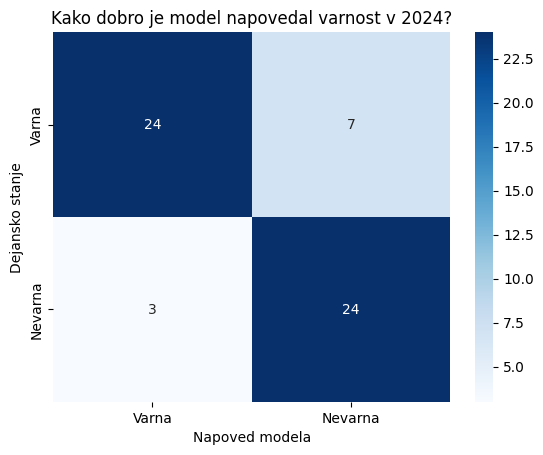

In [90]:
# --- 1. CELICA: GLAVNI MODEL (Out-of-Time Validacija) ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Priprava podatkov
# Meja za "Nevarno" je mediana zgodovine (da je pošteno)
meja = df_master[df_master['leto'] < 2024]['kriminaliteta_na_1000_preb'].median()
df_master['Target_Binary'] = (df_master['kriminaliteta_na_1000_preb'] > meja).astype(int)

features = [
    'delez_tujcev', 'delez_delovno_aktivnih', 'delez_moskih',
    'delez_edu_low', 'delez_edu_high', 'delez_edu_very_high',
    'delez_age_19_26', 'delez_age_65p', 'delez_age_0_14'
]

# 2. Razdelitev na PRETEKLOST (Učenje) in SEDANJOST (Test 2024)
train_mask = df_master['leto'] < 2024
test_mask = df_master['leto'] == 2024

X_train = df_master.loc[train_mask, features].fillna(0)
y_train = df_master.loc[train_mask, 'Target_Binary']

X_test = df_master.loc[test_mask, features].fillna(0)
y_test = df_master.loc[test_mask, 'Target_Binary']

# 3. Učenje modela
rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
rf.fit(X_train, y_train)

# 4. Rezultati
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"--- REZULTAT NAPOVEDI ZA LETO 2024 ---")
print(f"Točnost modela: {acc:.1%}")
print("\nConfusion Matrix (0=Varna, 1=Nevarna):")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Varna', 'Nevarna'], yticklabels=['Varna', 'Nevarna'])
plt.xlabel('Napoved modela')
plt.ylabel('Dejansko stanje')
plt.title('Kako dobro je model napovedal varnost v 2024?')
plt.show()

/tmp/ipython-input-160229896.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coeffs, x='Vpliv (Koeficient)', y='Faktor', palette=colors)


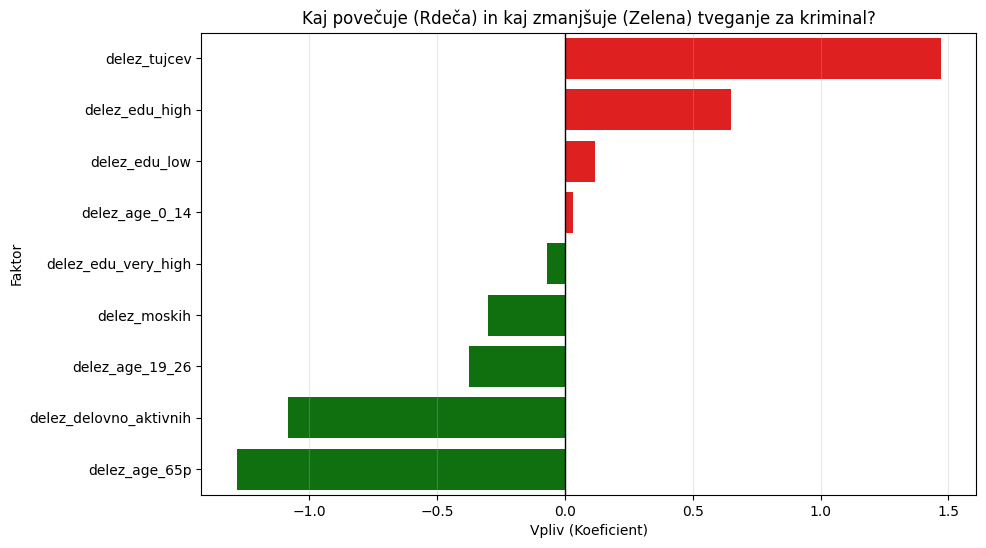

Interpretacija:
RDEČA (Desno): Več tega faktorja pomeni večjo verjetnost, da je občina NEVARNA.
ZELENA (Levo): Več tega faktorja pomeni večjo verjetnost, da je občina VARNA.


In [92]:
# --- 3. CELICA: SMER VPLIVA (Logistična regresija) ---
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Logistična regresija rabi standardizirane podatke
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Izpis koeficientov
coeffs = pd.DataFrame({
    'Faktor': features,
    'Vpliv (Koeficient)': log_reg.coef_[0]
}).sort_values(by='Vpliv (Koeficient)', ascending=False)

# Vizualizacija
plt.figure(figsize=(10, 6))
colors = ['red' if x > 0 else 'green' for x in coeffs['Vpliv (Koeficient)']]
sns.barplot(data=coeffs, x='Vpliv (Koeficient)', y='Faktor', palette=colors)
plt.title('Kaj povečuje (Rdeča) in kaj zmanjšuje (Zelena) tveganje za kriminal?')
plt.axvline(0, color='black', linewidth=1)
plt.grid(axis='x', alpha=0.3)
plt.show()

print("Interpretacija:")
print("RDEČA (Desno): Več tega faktorja pomeni večjo verjetnost, da je občina NEVARNA.")
print("ZELENA (Levo): Več tega faktorja pomeni večjo verjetnost, da je občina VARNA.")

In [94]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# --- XGBOOST ZA MAX TOČNOST ---
# Uporabimo iste podatke (X_train, y_train...) kot pri regresiji, ampak BREZ skaliranja (drevesa ne rabijo skaliranja)

# Model
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb.fit(X_train, y_train)

# Napoved
y_pred_xgb = xgb.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

print(f"--- XGBOOST REZULTAT ---")
print(f"Točnost napovedi za 2024: {acc_xgb:.1%}")

# Primerjava z Random Forestom (če ga imaš v spominu od prej)
print("\nČe je ta številka višja od 82.8%, je XGBoost zmagal.")
print("XGBoost je ponavadi boljši pri odkrivanju subtilnih vzorcev v podatkih.")

--- XGBOOST REZULTAT ---
Točnost napovedi za 2024: 77.6%

Če je ta številka višja od 82.8%, je XGBoost zmagal.
XGBoost je ponavadi boljši pri odkrivanju subtilnih vzorcev v podatkih.


#REGRESIJA


1. Regresija (Napovedovanje števila)
Cilj: Napovedati stopnjo kriminalitete (kriminaliteta_na_1000_preb) na podlagi demografskih podatkov. Model: RandomForestRegressor (naključni gozd) ali LinearRegression.

Zakaj? To je najbolj logična izbira. Želiš vedeti: "Če ima občina X prebivalcev, Y tujcev in Z zaposlenih, koliko kriminala lahko pričakujemo?"
Vhodni podatki (X): Prebivalstvo, delez_tujcev, st_delovno_aktivnih, delez_moskih (če ga imaš), leto.
Cilj (y): kriminaliteta_na_1000_preb.
2. Klasifikacija (Razvrščanje v razrede)
Cilj: Napovedati, ali je upravna enota VARNA, SREDNJA ali NEVARNA. Model: RandomForestClassifier ali GradientBoostingClassifier.

Priprava: Najprej moraš ustvariti nov stolpec (kategorijo).
Nizka: manj kot 10 dejanj na 1000 preb.
Srednja: med 10 in 20.
Visoka: nad 20.
Zakaj? To je lažje interpretirati za splošno javnost. "Ali je ta UE varna ali nevarna?"
Metrike: Accuracy, Confusion Matrix (da vidiš, kje se model zmoti).
3. Gručenje (Clustering)
Cilj: Najti naravne skupine upravnih enot brez vnaprejšnjih oznak. Model: KMeans.

Pristop: Uporabi podatke o strukturi (ne samo o kriminalu).
Uporabi: kriminaliteta_na_1000_preb, delez_tujcev, stopnja_aktivnosti.
Pričakovani rezultat: Verjetno boš dobil 3-4 gruče:
Mirno podeželje: (malo kriminala, malo tujcev).
Urbana središča: (veliko kriminala, veliko tujcev, velika aktivnost).
Specifična območja: (npr. obmejna območja).
Vizualizacija: Scatter plot, kjer so točke obarvane glede na gručo.
Želiš kodo za vse tri?
Lahko ti pripravim eno celico, kjer bodo vsi trije modeli (Regresija, Klasifikacija, Gručenje) implementirani zaporedoma. Tako boš imel celoten "Machine Learning" del rešen v enem kosu.

Naj ti pripravim to kodo?